<a href="https://colab.research.google.com/github/uavinash15/DataScience-/blob/main/ML_Projects/Apple_Stock_Prediction/Apple_stock_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Apple Stock Price Prediction for the Next 30 Days**

# Exploratory Data Analysis(EDA)

**Data Preparation and Exploration**

In [47]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data loading

In [48]:
apple_df=pd.read_csv('/content/P668 DATASET.csv')
apple_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [49]:
apple_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [50]:
apple_df['Date'] = pd.to_datetime(apple_df['Date'])
apple_df.set_index('Date', inplace=True)
print("DataFrame after converting 'Date' to datetime and setting as index:")
display(apple_df.head())

DataFrame after converting 'Date' to datetime and setting as index:


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


Initial Exploration

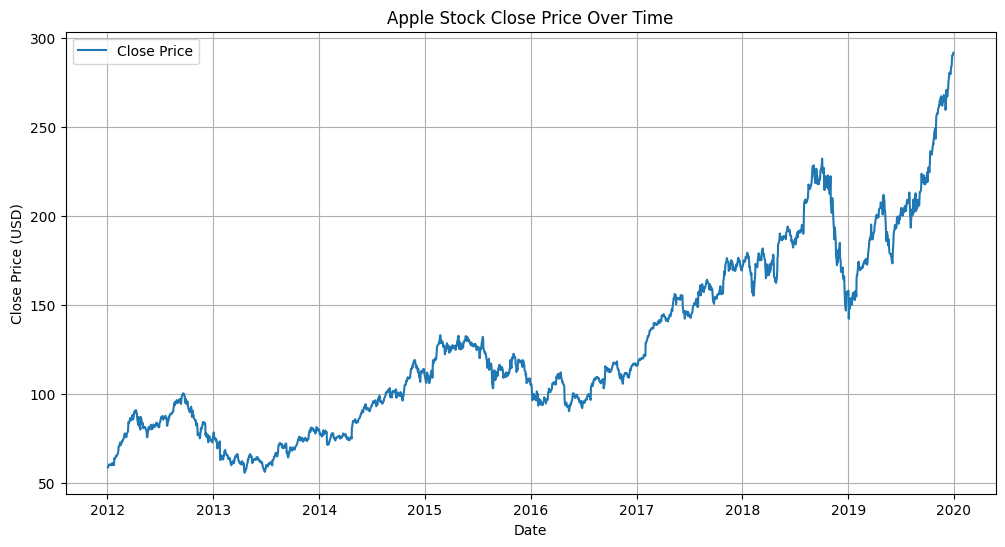

In [51]:
plt.figure(figsize=(12,6))
plt.plot(apple_df['Close'], label='Close Price')
plt.title('Apple Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

**Overall Trend**: The plot clearly shows the general direction of the stock price over the years. You can see periods of growth, stability, and potential downturns.

**Volatility**: Notice how much the price fluctuates daily. Areas with more jagged lines indicate higher volatility, while smoother sections suggest more stable periods.

**Anomalies/Significant Events**: Keep an eye out for any sudden, sharp drops or spikes that deviate significantly from the general trend. These could correspond to major news, economic events, or company-specific announcements.

Data Preprocessing

handling missing values

In [52]:
apple_df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


there are no missing values

### Handling Anomaly (Return-based Detection)
Instead of using IQR on price levels (which flags legitimate growth), we identify outliers based on extreme daily returns (spikes in volatility > 5 standard deviations).

In [53]:
apple_df['Daily_Return_Raw'] = apple_df['Close'].pct_change()
mean_ret = apple_df['Daily_Return_Raw'].mean()
std_ret = apple_df['Daily_Return_Raw'].std()

# Identify rows where single-day returns are extreme (> 5 standard deviations)
anomalies = apple_df[abs(apple_df['Daily_Return_Raw'] - mean_ret) > 5 * std_ret]

print(f"Number of return-based anomalies detected: {len(anomalies)}")
display(anomalies[['Close', 'Daily_Return_Raw']])

Number of return-based anomalies detected: 5


,Close,Daily_Return_Raw
Date,,
2012-04-25,87.142860,0.088741
2013-01-24,64.357140,-0.123558
2014-01-28,72.357140,-0.079927
2014-04-24,81.110001,0.081982
2019-01-03,142.190002,-0.099607


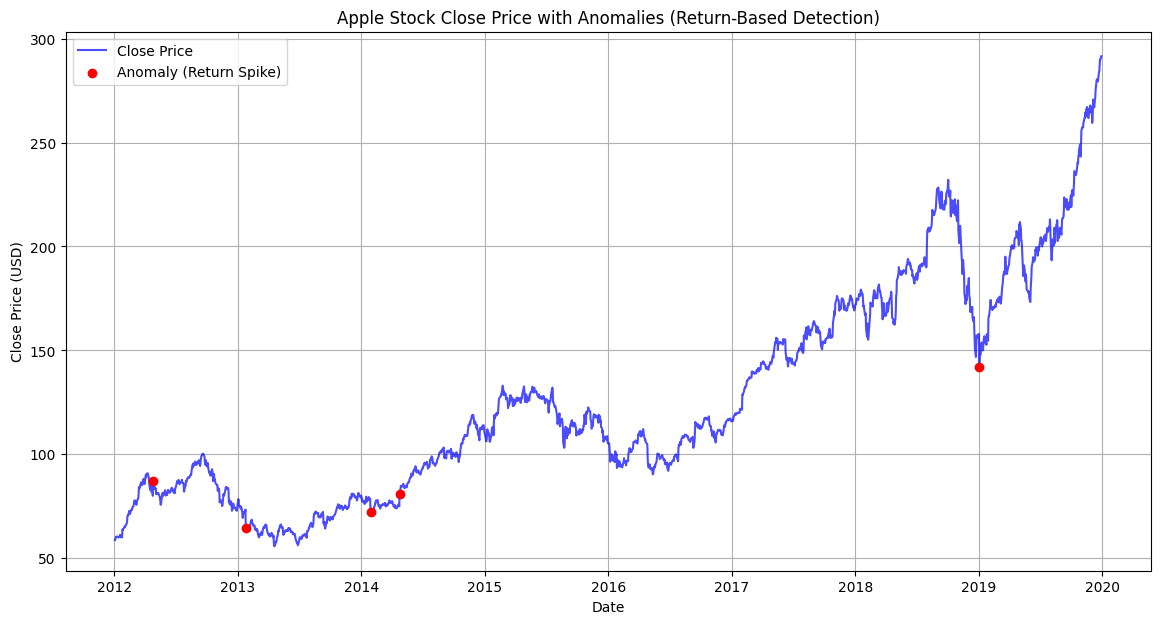

In [54]:
plt.figure(figsize=(14, 7))
plt.plot(apple_df['Close'], label='Close Price', color='blue', alpha=0.7)
plt.scatter(anomalies.index, anomalies['Close'], color='red', label='Anomaly (Return Spike)', zorder=5)
plt.title('Apple Stock Close Price with Anomalies (Return-Based Detection)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

Handling anomalies using Interpolation

In [55]:
apple_df_cleaned = apple_df.copy()

In [56]:
anomalies.index

DatetimeIndex(['2012-04-25', '2013-01-24', '2014-01-28', '2014-04-24',
               '2019-01-03'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [57]:
# Replacing identified anomalies with NaN to prepare for interpolation
apple_df_cleaned.loc[anomalies.index, 'Close'] = np.nan
print("Anomalies set to NaN for dates:")
print(anomalies.index)

Anomalies set to NaN for dates:
DatetimeIndex(['2012-04-25', '2013-01-24', '2014-01-28', '2014-04-24',
               '2019-01-03'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [58]:
apple_df_cleaned['Close'] = apple_df_cleaned['Close'].interpolate(method='linear') #Interpolation is a method of constructing new data points within the range of a discrete set of known data points. When we use interpolate() in pandas, especially with method='linear', it fills in missing values (NaNs) in a series or DataFrame by connecting the known data points with a straight line
apple_df_cleaned.loc[anomalies.index,'Close']

,Close
Date,
2012-04-25,83.427143
2013-01-24,68.135000
2014-01-28,75.089287
2014-04-24,78.334999
2019-01-03,153.089996


DataFrame after handling anomalies with interpolation

In [59]:
# Verifying values after interpolation
# First, we apply the interpolation
apple_df_cleaned['Close'] = apple_df_cleaned['Close'].interpolate(method='linear')

# Now, we check those specific dates again to ensure they are filled
print("Prices for anomaly dates after interpolation:")
display(apple_df_cleaned[apple_df_cleaned.index.isin(anomalies.index)][['Close']])

Prices for anomaly dates after interpolation:


,Close
Date,
2012-04-25,83.427143
2013-01-24,68.135000
2014-01-28,75.089287
2014-04-24,78.334999
2019-01-03,153.089996


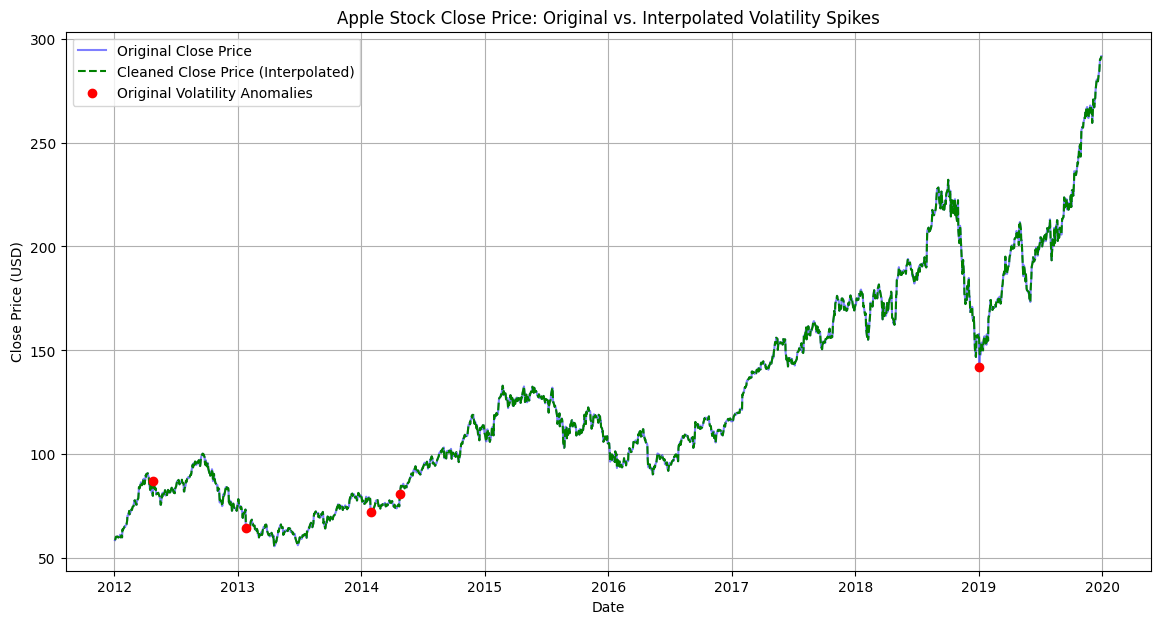

In [60]:
plt.figure(figsize=(14, 7))
plt.plot(apple_df['Close'], label='Original Close Price', color='blue', alpha=0.5)
plt.plot(apple_df_cleaned['Close'], label='Cleaned Close Price (Interpolated)', color='green', linestyle='--')
plt.scatter(anomalies.index, apple_df.loc[anomalies.index, 'Close'], color='red', label='Original Volatility Anomalies', zorder=5)
plt.title('Apple Stock Close Price: Original vs. Interpolated Volatility Spikes')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [267]:
# Cosmetic Cleanup: Removing the raw returns column used for anomaly detection
apple_df.drop(columns=['Daily_Return_Raw'], inplace=True)
print("Column 'Daily_Return_Raw' dropped from apple_df to maintain a clean dataset.")

Column 'Daily_Return_Raw' dropped from apple_df to maintain a clean dataset.


normalize stock price data

In [61]:
from sklearn.preprocessing import MinMaxScaler

In [62]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler

MinMaxScaler()

In [63]:
scaled_close_price = scaler.fit_transform(apple_df_cleaned['Close'].values.reshape(-1, 1))
scaled_close_price

array([[0.01254462],
       [0.01388393],
       [0.01666555],
       ...,
       [0.99317022],
       [0.99270351],
       [1.        ]])

In [64]:
apple_df_cleaned['Scaled_Close'] = scaled_close_price
apple_df_cleaned.head()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close
Date,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,NaN,0.012545
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,0.005374,0.013884
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,0.011102,0.016666
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,0.010454,0.019314
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,-0.001586,0.018908


# Feature Engineering

Moving Averages

simple Moving Average(SMA)

In [65]:
apple_df_cleaned['SMA_10'] = apple_df_cleaned['Close'].rolling(window=10).mean() #window=10 means it will consider the last 10 data points for each calculation.
apple_df_cleaned['SMA_10'].tail(10)

,SMA_10
Date,
2019-12-16,269.011996
2019-12-17,271.107996
2019-12-18,272.907996
2019-12-19,274.351996
2019-12-20,275.224997
2019-12-23,276.932996
2019-12-24,278.511993
2019-12-26,280.425995
2019-12-27,282.259995


In [66]:
apple_df_cleaned['SMA_30'] = apple_df_cleaned['Close'].rolling(window=30).mean()
apple_df_cleaned['SMA_30'].tail(30)

,SMA_30
Date,
2019-11-15,246.150001
2019-11-18,247.484668
2019-11-19,248.881001
2019-11-20,250.086335
2019-11-21,251.150335
2019-11-22,252.002668
2019-11-25,253.019335
2019-11-26,253.985002
2019-11-27,255.100668


Exponential Moving Averages (EMA)

In [67]:
apple_df_cleaned['EMA_10'] = apple_df_cleaned['Close'].ewm(span=10, adjust=False).mean()
apple_df_cleaned['EMA_10'].tail(10)

,EMA_10
Date,
2019-12-16,270.977127
2019-12-17,272.692195
2019-12-18,273.973613
2019-12-19,275.072954
2019-12-20,275.866963
2019-12-23,277.345697
2019-12-24,278.604659
2019-12-26,280.660176
2019-12-27,282.321960


In [68]:
apple_df_cleaned['EMA_30'] = apple_df_cleaned['Close'].ewm(span=30, adjust=False).mean()
apple_df_cleaned['EMA_30'].tail(30)

,EMA_30
Date,
2019-11-15,247.925209
2019-11-18,249.162292
2019-11-19,250.267306
2019-11-20,251.101029
2019-11-21,251.804834
2019-11-22,252.448393
2019-11-25,253.346561
2019-11-26,254.052590
2019-11-27,254.942100


In [69]:
display(apple_df_cleaned.head(35))

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,EMA_10,EMA_30
Date,,,,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,NaN,0.012545,NaN,NaN,58.747143,58.747143
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,0.005374,0.013884,NaN,NaN,58.804546,58.767512
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,0.011102,0.016666,NaN,NaN,58.970732,58.828870
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,0.010454,0.019314,NaN,NaN,59.220210,58.926547
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,-0.001586,0.018908,NaN,NaN,59.406925,59.011747
2012-01-10,60.844284,60.857143,60.214287,60.462856,52.248333,64549100,0.003580,0.019823,NaN,NaN,59.598912,59.105367
2012-01-11,60.382858,60.407143,59.901428,60.364285,52.163139,53771200,-0.001630,0.019405,NaN,NaN,59.738071,59.186587
2012-01-12,60.325714,60.414288,59.821430,60.198570,52.019955,53146800,-0.002745,0.018702,NaN,NaN,59.821798,59.251876
2012-01-13,59.957142,60.064285,59.808571,59.972858,51.824898,56505400,-0.003749,0.017744,NaN,NaN,59.849263,59.298391


In [70]:
display(apple_df_cleaned.tail(35))

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,EMA_10,EMA_30
Date,,,,,,,,,,,,
2019-11-08,258.690002,260.440002,256.850006,260.140015,258.357635,17496600,0.002737,0.866882,253.162000,239.427333,253.764070,241.756617
2019-11-11,258.299988,262.470001,258.279999,262.200012,260.403503,20455300,0.007919,0.875621,254.477001,240.701667,255.297877,243.075546
2019-11-12,261.549988,262.790009,260.920013,261.959991,260.165131,21847200,-0.000915,0.874602,256.344000,241.947333,256.509171,244.293897
2019-11-13,261.130005,264.779999,261.070007,264.470001,262.657959,25683600,0.009582,0.885250,258.465001,243.464333,257.956594,245.595582
2019-11-14,263.750000,264.880005,262.100006,262.640015,260.840485,22295700,-0.006919,0.877487,259.853003,244.858333,258.808125,246.695222
2019-11-15,263.679993,265.779999,263.010010,265.760010,263.939117,25051600,0.011879,0.890723,260.847003,246.150001,260.072104,247.925209
2019-11-18,265.799988,267.429993,264.230011,267.100006,265.269958,21675800,0.005042,0.896407,261.807004,247.484668,261.349905,249.162292
2019-11-19,267.899994,268.000000,265.390015,266.290009,264.465485,19041800,-0.003033,0.892971,262.723004,248.881001,262.248106,250.267306
2019-11-20,265.540009,266.079987,260.399994,263.190002,261.386749,26558600,-0.011641,0.879820,263.318005,250.086335,262.419359,251.101029


**volatality Measures**

In [71]:
#Calculating daily returns for volatility
apple_df_cleaned['Daily_Return'] = apple_df_cleaned['Close'].pct_change()
apple_df_cleaned.head()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,EMA_10,EMA_30,Daily_Return
Date,,,,,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,NaN,0.012545,NaN,NaN,58.747143,58.747143,NaN
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,0.005374,0.013884,NaN,NaN,58.804546,58.767512,0.005374
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,0.011102,0.016666,NaN,NaN,58.970732,58.828870,0.011102
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,0.010454,0.019314,NaN,NaN,59.220210,58.926547,0.010454
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,-0.001586,0.018908,NaN,NaN,59.406925,59.011747,-0.001586


In [72]:
# Calculating Volatility (Standard Deviation of Daily Returns over a 30-day window)
apple_df_cleaned['Volatility'] = apple_df_cleaned['Daily_Return'].rolling(window=30).std()
apple_df_cleaned.tail()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,EMA_10,EMA_30,Daily_Return,Volatility
Date,,,,,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.016318,0.968099,276.932996,268.701334,277.345697,268.035151,0.016318,0.010186
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.000951,0.969244,278.511993,269.436999,278.604659,269.082560,0.000951,0.010149
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.019840,0.993170,280.425995,270.368667,280.660176,270.426266,0.019840,0.010589
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,-0.000379,0.992704,282.259995,271.212999,282.321960,271.676184,-0.000379,0.010545
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,0.005935,1.000000,283.896994,272.175665,283.994329,272.956429,0.005935,0.010384


In [73]:
# Calculating Bollinger Bands
# Middle Band is typically a 20-day SMA

In [74]:
window = 20
apple_df_cleaned['Middle_Band'] = apple_df_cleaned['Close'].rolling(window=window).mean()
apple_df_cleaned.tail()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,EMA_10,EMA_30,Daily_Return,Volatility,Middle_Band
Date,,,,,,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.016318,0.968099,276.932996,268.701334,277.345697,268.035151,0.016318,0.010186,271.181998
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.000951,0.969244,278.511993,269.436999,278.604659,269.082560,0.000951,0.010149,272.076997
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.019840,0.993170,280.425995,270.368667,280.660176,270.426266,0.019840,0.010589,273.357997
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,-0.000379,0.992704,282.259995,271.212999,282.321960,271.676184,-0.000379,0.010545,274.455997
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,0.005935,1.000000,283.896994,272.175665,283.994329,272.956429,0.005935,0.010384,275.669496


In [75]:
# Upper Band is Middle Band + (2 * Standard Deviation of Close Price over the window)
apple_df_cleaned['Upper_Band'] = apple_df_cleaned['Middle_Band'] + (apple_df_cleaned['Close'].rolling(window=window).std() * 2)
apple_df_cleaned.tail()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,EMA_10,EMA_30,Daily_Return,Volatility,Middle_Band,Upper_Band
Date,,,,,,,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.016318,0.968099,276.932996,268.701334,277.345697,268.035151,0.016318,0.010186,271.181998,285.624298
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.000951,0.969244,278.511993,269.436999,278.604659,269.082560,0.000951,0.010149,272.076997,287.452130
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.019840,0.993170,280.425995,270.368667,280.660176,270.426266,0.019840,0.010589,273.357997,290.200516
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,-0.000379,0.992704,282.259995,271.212999,282.321960,271.676184,-0.000379,0.010545,274.455997,292.597042
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,0.005935,1.000000,283.896994,272.175665,283.994329,272.956429,0.005935,0.010384,275.669496,294.989598


In [76]:
# Lower Band is Middle Band - (2 * Standard Deviation of Close Price over the window)
apple_df_cleaned['Lower_Band'] = apple_df_cleaned['Middle_Band'] - (apple_df_cleaned['Close'].rolling(window=window).std() * 2)
apple_df_cleaned.tail()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,EMA_10,EMA_30,Daily_Return,Volatility,Middle_Band,Upper_Band,Lower_Band
Date,,,,,,,,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.016318,0.968099,276.932996,268.701334,277.345697,268.035151,0.016318,0.010186,271.181998,285.624298,256.739698
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.000951,0.969244,278.511993,269.436999,278.604659,269.082560,0.000951,0.010149,272.076997,287.452130,256.701865
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.019840,0.993170,280.425995,270.368667,280.660176,270.426266,0.019840,0.010589,273.357997,290.200516,256.515479
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,-0.000379,0.992704,282.259995,271.212999,282.321960,271.676184,-0.000379,0.010545,274.455997,292.597042,256.314952
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,0.005935,1.000000,283.896994,272.175665,283.994329,272.956429,0.005935,0.010384,275.669496,294.989598,256.349395


### Other Technical Indicators (RSI, MACD, OBV)

In [77]:
# Calculate Relative Strength Index (RSI)
# RSI typically uses a 14-period window
rsi_period = 14

delta = apple_df_cleaned['Close'].diff()

# Gain if the current close is greater than the previous close, else 0
gain = delta.mask(delta < 0, 0)
# Loss if the current close is less than the previous close, else 0 (absolute value)
loss = -delta.mask(delta > 0, 0)

avg_gain = gain.ewm(com=rsi_period - 1, adjust=False).mean()
avg_loss = loss.ewm(com=rsi_period - 1, adjust=False).mean()

rs = avg_gain / avg_loss
apple_df_cleaned['RSI'] = 100 - (100 / (1 + rs))

print("RSI (Relative Strength Index):")
display(apple_df_cleaned[['Close', 'RSI']].tail())

RSI (Relative Strength Index):


,Close,RSI
Date,,
2019-12-23,284.000000,74.208465
2019-12-24,284.269989,74.436585
2019-12-26,289.910004,78.678994
2019-12-27,289.799988,78.405655
2019-12-30,291.519989,79.598962


In [78]:
# Calculate Moving Average Convergence Divergence (MACD)
# MACD typically uses 12-period EMA, 26-period EMA, and 9-period EMA for the signal line
exp1 = apple_df_cleaned['Close'].ewm(span=12, adjust=False).mean()
exp2 = apple_df_cleaned['Close'].ewm(span=26, adjust=False).mean()
apple_df_cleaned['MACD'] = exp1 - exp2
apple_df_cleaned['Signal_Line'] = apple_df_cleaned['MACD'].ewm(span=9, adjust=False).mean()

print("MACD (Moving Average Convergence Divergence):")
display(apple_df_cleaned[['Close', 'MACD', 'Signal_Line']].tail())

MACD (Moving Average Convergence Divergence):


,Close,MACD,Signal_Line
Date,,,
2019-12-23,284.000000,6.466477,5.850753
2019-12-24,284.269989,6.626611,6.005924
2019-12-26,289.910004,7.126471,6.230034
2019-12-27,289.799988,7.428110,6.469649
2019-12-30,291.519989,7.716994,6.719118


In [79]:
# Calculate On-Balance Volume (OBV)
# OBV is a cumulative indicator that relates volume to price changes.
apple_df_cleaned['OBV'] = (np.sign(apple_df_cleaned['Close'].diff()) * apple_df_cleaned['Volume']).fillna(0).cumsum()

print("OBV (On-Balance Volume):")
display(apple_df_cleaned[['Close', 'Volume', 'OBV']].tail())

OBV (On-Balance Volume):


,Close,Volume,OBV
Date,,,
2019-12-23,284.000000,24643000,726489100.0
2019-12-24,284.269989,12119700,738608800.0
2019-12-26,289.910004,23280300,761889100.0
2019-12-27,289.799988,36566500,725322600.0
2019-12-30,291.519989,36028600,761351200.0


In [80]:
display(apple_df_cleaned.tail())

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,...,EMA_30,Daily_Return,Volatility,Middle_Band,Upper_Band,Lower_Band,RSI,MACD,Signal_Line,OBV
Date,,,,,,,,,,,,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.016318,0.968099,276.932996,268.701334,...,268.035151,0.016318,0.010186,271.181998,285.624298,256.739698,74.208465,6.466477,5.850753,726489100.0
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.000951,0.969244,278.511993,269.436999,...,269.082560,0.000951,0.010149,272.076997,287.452130,256.701865,74.436585,6.626611,6.005924,738608800.0
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.019840,0.993170,280.425995,270.368667,...,270.426266,0.019840,0.010589,273.357997,290.200516,256.515479,78.678994,7.126471,6.230034,761889100.0
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,-0.000379,0.992704,282.259995,271.212999,...,271.676184,-0.000379,0.010545,274.455997,292.597042,256.314952,78.405655,7.428110,6.469649,725322600.0
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,0.005935,1.000000,283.896994,272.175665,...,272.956429,0.005935,0.010384,275.669496,294.989598,256.349395,79.598962,7.716994,6.719118,761351200.0


In [81]:
display(apple_df_cleaned.head())

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,...,EMA_30,Daily_Return,Volatility,Middle_Band,Upper_Band,Lower_Band,RSI,MACD,Signal_Line,OBV
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,NaN,0.012545,NaN,NaN,...,58.747143,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,0.005374,0.013884,NaN,NaN,...,58.767512,0.005374,NaN,NaN,NaN,NaN,100.000000,0.025185,0.005037,65005500.0
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,0.011102,0.016666,NaN,NaN,...,58.828870,0.011102,NaN,NaN,NaN,NaN,100.000000,0.096938,0.023417,132822900.0
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,0.010454,0.019314,NaN,NaN,...,58.926547,0.010454,NaN,NaN,NaN,NaN,100.000000,0.201850,0.059104,212396100.0
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,-0.001586,0.018908,NaN,NaN,...,59.011747,-0.001586,NaN,NaN,NaN,NaN,97.997494,0.274111,0.102105,113890000.0


**Incorporating external financial indicators**

S&amp;P 500 trends

In [82]:
import yfinance as yf    #yfinannce=Yahoo finance

In [83]:
sp500_ticker = '^GSPC' # Ticker for S&P 500    , A ticker symbol (or just 'ticker') is a short, alphanumeric code that uniquely identifies publicly traded shares of a particular stock or other financial instrument on a stock market.
sp500_data = yf.download(sp500_ticker, start='2012-01-01', end='2019-12-31')

/tmp/ipykernel_4707/86218285.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download(sp500_ticker, start='2012-01-01', end='2019-12-31')
[*********************100%***********************]  1 of 1 completed


In [84]:
# Keeping only the 'Close' price for simplicity and renaming the column
sp500_df_yf = sp500_data[['Close']].copy()
sp500_df_yf.columns = [sp500_ticker] # Renaming column to ticker for clarity
sp500_df_yf.head()

,^GSPC
Date,
2012-01-03,1277.060059
2012-01-04,1277.300049
2012-01-05,1281.060059
2012-01-06,1277.810059
2012-01-09,1280.699951


**Inflation rates**

For this particular project, focusing on a 30-day prediction for Apple's stock price, my advice is to not prioritize incorporating inflation rates at this point. The impact of inflation is generally more relevant for longer-term economic analyses or broader market predictions. You have already included the S&P 500, which captures much of the general market sentiment.

Earning Reports

In [85]:
# Defining the ticker for Apple
apple_ticker = 'AAPL'
apple_ticker

'AAPL'

Fetch earnings calendar data
Note: yfinance's earnings calendar can be a bit tricky and might not always return
a clean DataFrame directly for historical dates in the same way as historical prices.
We often need to iterate or use specific methods if available.
For simplicity, let's fetch the stock object and try to access earnings dates.

In [86]:
stock = yf.Ticker(apple_ticker)
stock

yfinance.Ticker object <AAPL>

->Get earnings dates (sometimes available as a DataFrame or dictionary)
->This method usually gives upcoming earnings, but we can try to access historical if available.
->For robust historical earnings, you might need a dedicated API or manual lookup.
->As a demonstration, let's look at the available info which might include a 'calendar' or 'earnings' key.

->A more direct way to get historical quarterly earnings for plotting
->is often through its financial statements, but for event dates, we'd typically look for a calendar.
->Let's try to get a proxy for earnings event by looking at events data

->For simplicity and to show a concrete example, we'll often look for the 'calendar' attribute
->which might contain earnings dates.

->This often returns *upcoming* earnings dates. For historical, a direct yfinance method isn't
->as straightforward as 'download'. You might need to parse financial statements or use another library/API.

->Let's simulate how you would integrate event data if you had the dates:
->For demonstration, assume we have a list of earnings dates (you would get this from a proper source)
->Example (these are placeholders, you'd replace with actual dates for AAPL):

In [87]:
# Apple Inc. verified quarterly earnings report dates (2012–2019)
# Source: Apple investor relations historical earnings calendar
# These dates are used as binary event flags in the feature set
earning_dates = pd.to_datetime([
    # 2012
    '2012-01-24', '2012-04-24', '2012-07-24', '2012-10-25',
    # 2013
    '2013-01-23', '2013-04-23', '2013-07-23', '2013-10-28',
    # 2014
    '2014-01-27', '2014-04-23', '2014-07-22', '2014-10-20',
    # 2015
    '2015-01-27', '2015-04-27', '2015-07-21', '2015-10-27',
    # 2016
    '2016-01-26', '2016-04-26', '2016-07-26', '2016-10-25',
    # 2017
    '2017-02-01', '2017-05-02', '2017-08-01', '2017-11-02',
    # 2018
    '2018-02-01', '2018-05-01', '2018-07-31', '2018-11-01',
    # 2019
    '2019-01-29', '2019-04-30', '2019-07-30', '2019-10-30'
])

Creating an 'Earnings_Report' feature in cleaned DataFrame

In [88]:
apple_df_cleaned['Earnings_Report'] = apple_df_cleaned.index.isin(earning_dates).astype(int)

In [89]:
apple_df_cleaned[['Close', 'Earnings_Report']].head()

,Close,Earnings_Report
Date,,
2012-01-03,58.747143,0
2012-01-04,59.062859,0
2012-01-05,59.718571,0
2012-01-06,60.342857,0
2012-01-09,60.247143,0


In [90]:
apple_df_cleaned[['Close', 'Earnings_Report']].tail()

,Close,Earnings_Report
Date,,
2019-12-23,284.000000,0
2019-12-24,284.269989,0
2019-12-26,289.910004,0
2019-12-27,289.799988,0
2019-12-30,291.519989,0


In [91]:
apple_df_cleaned.head()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,...,Daily_Return,Volatility,Middle_Band,Upper_Band,Lower_Band,RSI,MACD,Signal_Line,OBV,Earnings_Report
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,NaN,0.012545,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,0.005374,0.013884,NaN,NaN,...,0.005374,NaN,NaN,NaN,NaN,100.000000,0.025185,0.005037,65005500.0,0
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,0.011102,0.016666,NaN,NaN,...,0.011102,NaN,NaN,NaN,NaN,100.000000,0.096938,0.023417,132822900.0,0
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,0.010454,0.019314,NaN,NaN,...,0.010454,NaN,NaN,NaN,NaN,100.000000,0.201850,0.059104,212396100.0,0
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,-0.001586,0.018908,NaN,NaN,...,-0.001586,NaN,NaN,NaN,NaN,97.997494,0.274111,0.102105,113890000.0,0


In [92]:
apple_df_cleaned.tail()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,...,Daily_Return,Volatility,Middle_Band,Upper_Band,Lower_Band,RSI,MACD,Signal_Line,OBV,Earnings_Report
Date,,,,,,,,,,,,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.016318,0.968099,276.932996,268.701334,...,0.016318,0.010186,271.181998,285.624298,256.739698,74.208465,6.466477,5.850753,726489100.0,0
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.000951,0.969244,278.511993,269.436999,...,0.000951,0.010149,272.076997,287.452130,256.701865,74.436585,6.626611,6.005924,738608800.0,0
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.019840,0.993170,280.425995,270.368667,...,0.019840,0.010589,273.357997,290.200516,256.515479,78.678994,7.126471,6.230034,761889100.0,0
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,-0.000379,0.992704,282.259995,271.212999,...,-0.000379,0.010545,274.455997,292.597042,256.314952,78.405655,7.428110,6.469649,725322600.0,0
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,0.005935,1.000000,283.896994,272.175665,...,0.005935,0.010384,275.669496,294.989598,256.349395,79.598962,7.716994,6.719118,761351200.0,0


### Seasonality Features

In [93]:
# Extracting time-based features for seasonality analysis
apple_df_cleaned['Month'] = apple_df_cleaned.index.month
apple_df_cleaned['Quarter'] = apple_df_cleaned.index.quarter
apple_df_cleaned['DayOfWeek'] = apple_df_cleaned.index.dayofweek # Monday=0, Sunday=6
apple_df_cleaned.head()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,...,Upper_Band,Lower_Band,RSI,MACD,Signal_Line,OBV,Earnings_Report,Month,Quarter,DayOfWeek
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,NaN,0.012545,NaN,NaN,...,NaN,NaN,NaN,0.000000,0.000000,0.0,0,1,1,1
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,0.005374,0.013884,NaN,NaN,...,NaN,NaN,100.000000,0.025185,0.005037,65005500.0,0,1,1,2
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,0.011102,0.016666,NaN,NaN,...,NaN,NaN,100.000000,0.096938,0.023417,132822900.0,0,1,1,3
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,0.010454,0.019314,NaN,NaN,...,NaN,NaN,100.000000,0.201850,0.059104,212396100.0,0,1,1,4
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,-0.001586,0.018908,NaN,NaN,...,NaN,NaN,97.997494,0.274111,0.102105,113890000.0,0,1,1,0


### Visualizing Seasonality

/tmp/ipykernel_4707/654358140.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day', y='Close', data=day_of_week_avg, ax=axes[2], palette='viridis')


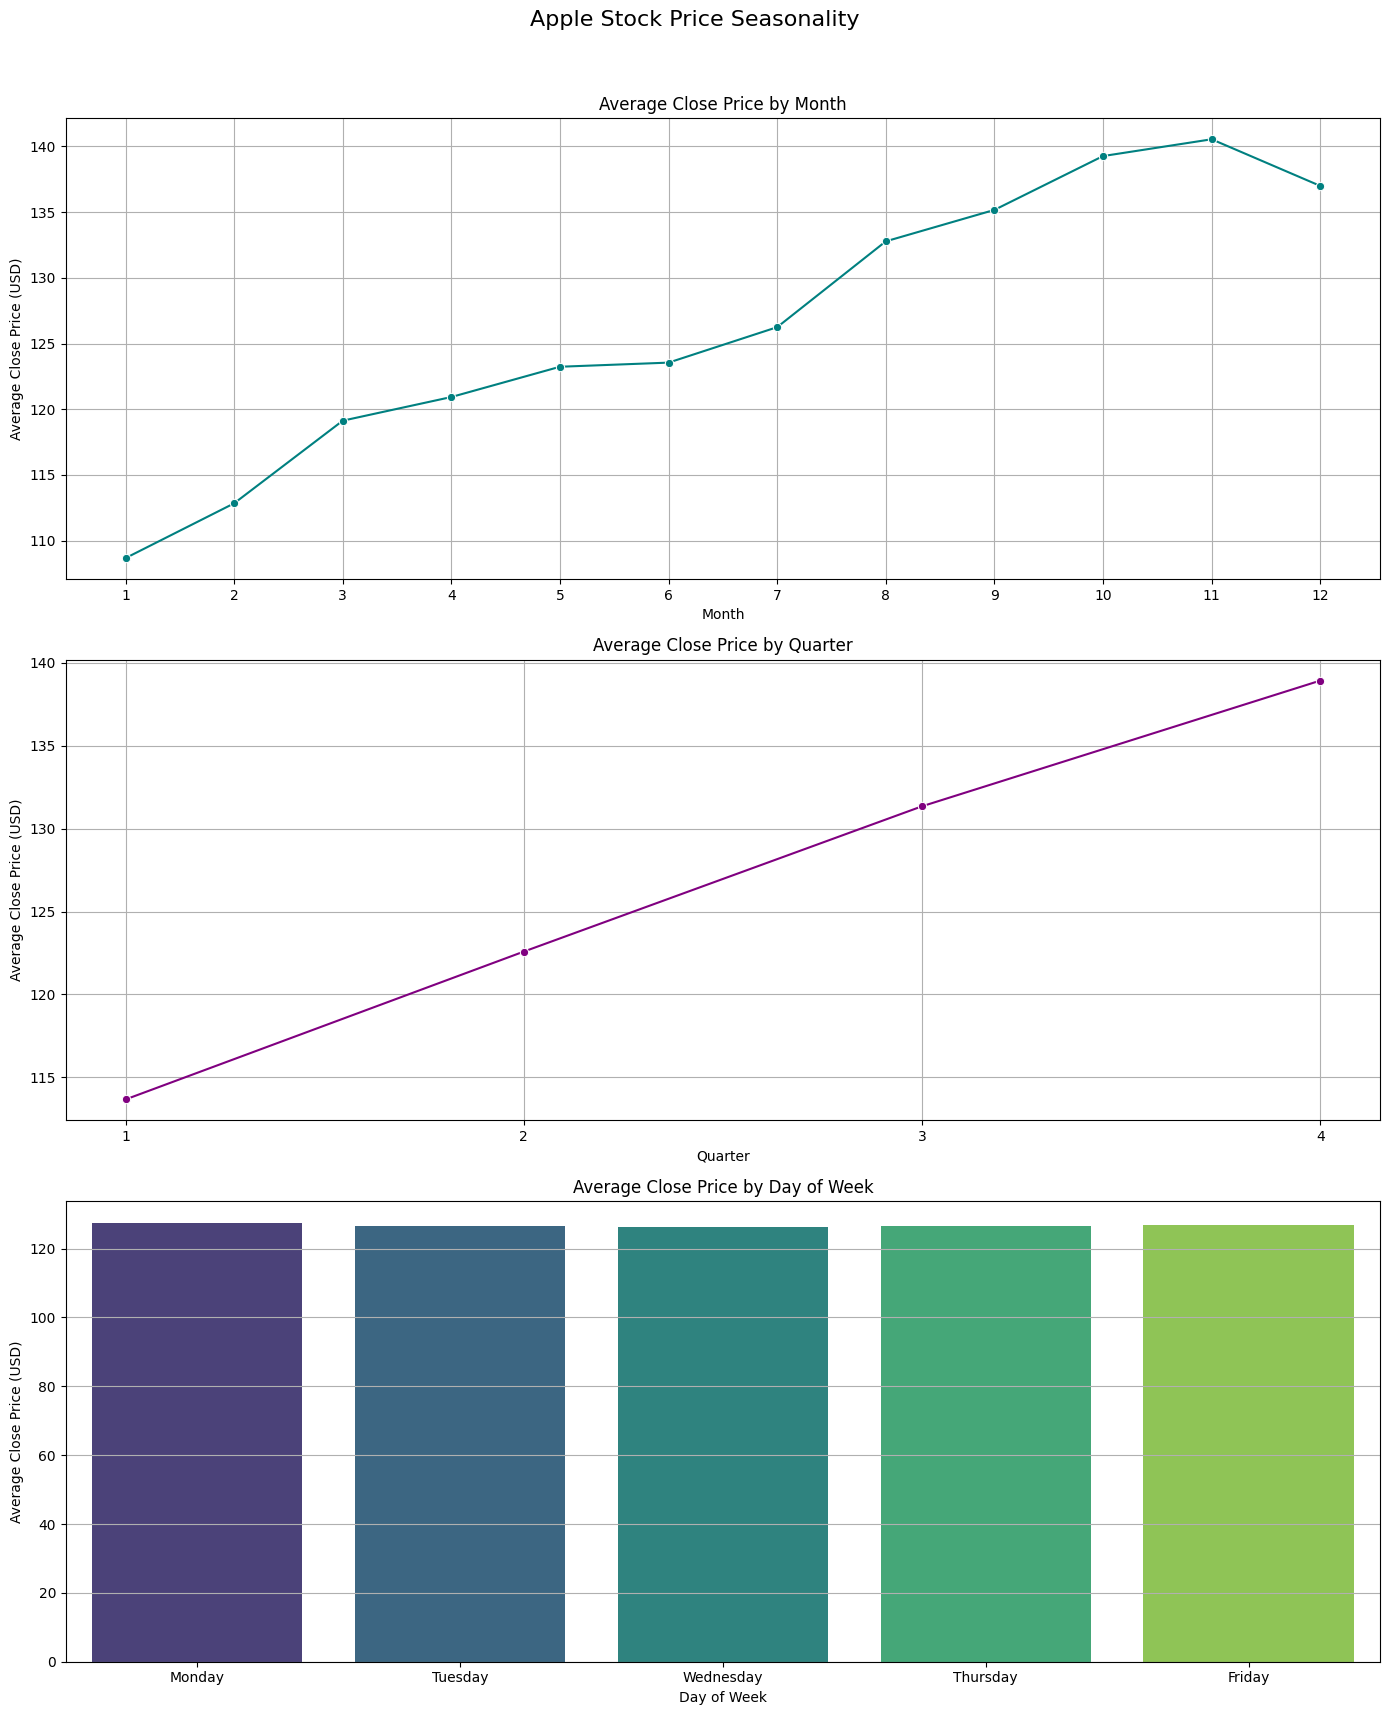

In [94]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle('Apple Stock Price Seasonality', fontsize=16)

# Monthly Seasonality
sns.lineplot(x='Month', y='Close', data=apple_df_cleaned.groupby('Month')['Close'].mean().reset_index(), ax=axes[0], marker='o', color='teal')
axes[0].set_title('Average Close Price by Month')
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Close Price (USD)')
axes[0].grid(True)

# Quarterly Seasonality
sns.lineplot(x='Quarter', y='Close', data=apple_df_cleaned.groupby('Quarter')['Close'].mean().reset_index(), ax=axes[1], marker='o', color='purple')
axes[1].set_title('Average Close Price by Quarter')
axes[1].set_xticks(range(1, 5))
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Average Close Price (USD)')
axes[1].grid(True)

# Day of Week Seasonality
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week_avg = apple_df_cleaned.groupby('DayOfWeek')['Close'].mean().reset_index()
day_of_week_avg['Day'] = day_of_week_avg['DayOfWeek'].map(lambda x: day_names[x])
sns.barplot(x='Day', y='Close', data=day_of_week_avg, ax=axes[2], palette='viridis')
axes[2].set_title('Average Close Price by Day of Week')
axes[2].set_xlabel('Day of Week')
axes[2].set_ylabel('Average Close Price (USD)')
axes[2].grid(axis='y')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Lagged Features

In [95]:
# Creating lagged features for 'Close' price
# Lag 1: Previous day's close price
apple_df_cleaned['Close_Lag_1'] = apple_df_cleaned['Close'].shift(1)

# Lag 5: Close price from 5 days ago (approx. one trading week)
apple_df_cleaned['Close_Lag_5'] = apple_df_cleaned['Close'].shift(5)

# Lag 30: Close price from 30 days ago (approx. one trading month)
apple_df_cleaned['Close_Lag_30'] = apple_df_cleaned['Close'].shift(30)

In [96]:
apple_df_cleaned.head()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,...,MACD,Signal_Line,OBV,Earnings_Report,Month,Quarter,DayOfWeek,Close_Lag_1,Close_Lag_5,Close_Lag_30
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,NaN,0.012545,NaN,NaN,...,0.000000,0.000000,0.0,0,1,1,1,NaN,NaN,NaN
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,0.005374,0.013884,NaN,NaN,...,0.025185,0.005037,65005500.0,0,1,1,2,58.747143,NaN,NaN
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,0.011102,0.016666,NaN,NaN,...,0.096938,0.023417,132822900.0,0,1,1,3,59.062859,NaN,NaN
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,0.010454,0.019314,NaN,NaN,...,0.201850,0.059104,212396100.0,0,1,1,4,59.718571,NaN,NaN
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,-0.001586,0.018908,NaN,NaN,...,0.274111,0.102105,113890000.0,0,1,1,0,60.342857,NaN,NaN


In [97]:
apple_df_cleaned.tail()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,...,MACD,Signal_Line,OBV,Earnings_Report,Month,Quarter,DayOfWeek,Close_Lag_1,Close_Lag_5,Close_Lag_30
Date,,,,,,,,,,,,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.016318,0.968099,276.932996,268.701334,...,6.466477,5.850753,726489100.0,0,12,4,0,279.440002,279.859985,260.140015
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.000951,0.969244,278.511993,269.436999,...,6.626611,6.005924,738608800.0,0,12,4,1,284.000000,280.410004,262.200012
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.019840,0.993170,280.425995,270.368667,...,7.126471,6.230034,761889100.0,0,12,4,3,284.269989,279.739990,261.959991
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,-0.000379,0.992704,282.259995,271.212999,...,7.428110,6.469649,725322600.0,0,12,4,4,289.910004,280.019989,264.470001
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,0.005935,1.000000,283.896994,272.175665,...,7.716994,6.719118,761351200.0,0,12,4,0,289.799988,279.440002,262.640015


## Comprehensive Statistical Summary

In [98]:
display(apple_df_cleaned.describe())

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,...,MACD,Signal_Line,OBV,Earnings_Report,Month,Quarter,DayOfWeek,Close_Lag_1,Close_Lag_5,Close_Lag_30
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03,2010.000000,2011.000000,2002.000000,1982.000000,...,2011.000000,2011.000000,2.011000e+03,2011.000000,2011.000000,2011.000000,2011.000000,2010.000000,2006.000000,1981.000000
mean,126.707469,127.827594,125.580258,126.746664,119.505548,5.949670e+07,0.000928,0.301008,126.538201,126.125529,...,0.731299,0.717935,1.782787e+08,0.015912,6.534560,2.513178,2.022874,126.664688,126.344986,124.544307
std,50.483753,50.926301,50.124940,50.579735,52.438444,4.683856e+07,0.016124,0.214566,49.949137,48.719859,...,2.644963,2.513926,7.132744e+08,0.125168,3.422369,1.113553,1.402015,50.458517,49.997394,47.649584
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07,-0.123558,0.000000,58.104428,60.068000,...,-11.052513,-9.551421,-1.942209e+09,0.000000,1.000000,1.000000,0.000000,55.790001,55.790001,55.790001
25%,85.882858,86.717858,85.056427,86.107143,75.056679,2.758565e+07,-0.006752,0.128610,85.709644,85.700958,...,-0.531211,-0.517883,-2.732735e+08,0.000000,4.000000,2.000000,1.000000,86.089285,85.921428,85.557144
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07,0.000715,0.242905,112.916000,112.912333,...,0.782815,0.795241,2.849498e+08,0.000000,7.000000,3.000000,2.000000,113.025002,112.960003,112.480003
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07,0.009571,0.464324,165.006501,165.031667,...,2.288341,2.137082,5.177040e+08,0.000000,10.000000,4.000000,3.000000,165.165004,164.177502,160.949997
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08,0.088741,1.000000,283.896994,272.175665,...,8.818681,8.468222,3.205381e+09,1.000000,12.000000,4.000000,4.000000,289.910004,280.410004,264.470001


This `describe()` output gives a quick overview of the central tendency, dispersion, and shape of the distribution of each column.

Next, let's merge the S&P 500 data into our cleaned DataFrame so we can analyze its relationship with Apple's stock price.

In [99]:
# Merge S&P 500 data into the main DataFrame
apple_df_cleaned = apple_df_cleaned.merge(sp500_df_yf, left_index=True, right_index=True, how='left')

# Rename the S&P 500 column for clarity
apple_df_cleaned.rename(columns={'^GSPC': 'SP500_Close'}, inplace=True)

print("DataFrame after merging S&P 500 data:")
display(apple_df_cleaned.head())

DataFrame after merging S&P 500 data:


,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,...,Signal_Line,OBV,Earnings_Report,Month,Quarter,DayOfWeek,Close_Lag_1,Close_Lag_5,Close_Lag_30,SP500_Close
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,NaN,0.012545,NaN,NaN,...,0.000000,0.0,0,1,1,1,NaN,NaN,NaN,1277.060059
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,0.005374,0.013884,NaN,NaN,...,0.005037,65005500.0,0,1,1,2,58.747143,NaN,NaN,1277.300049
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,0.011102,0.016666,NaN,NaN,...,0.023417,132822900.0,0,1,1,3,59.062859,NaN,NaN,1281.060059
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,0.010454,0.019314,NaN,NaN,...,0.059104,212396100.0,0,1,1,4,59.718571,NaN,NaN,1277.810059
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,-0.001586,0.018908,NaN,NaN,...,0.102105,113890000.0,0,1,1,0,60.342857,NaN,NaN,1280.699951


## Focused Correlation Analysis

To better understand the relationships between the most relevant features for our prediction task, let's create a correlation heatmap with a selected subset of columns. This will help us identify strong predictors for Apple's stock price and potential multicollinearity issues.

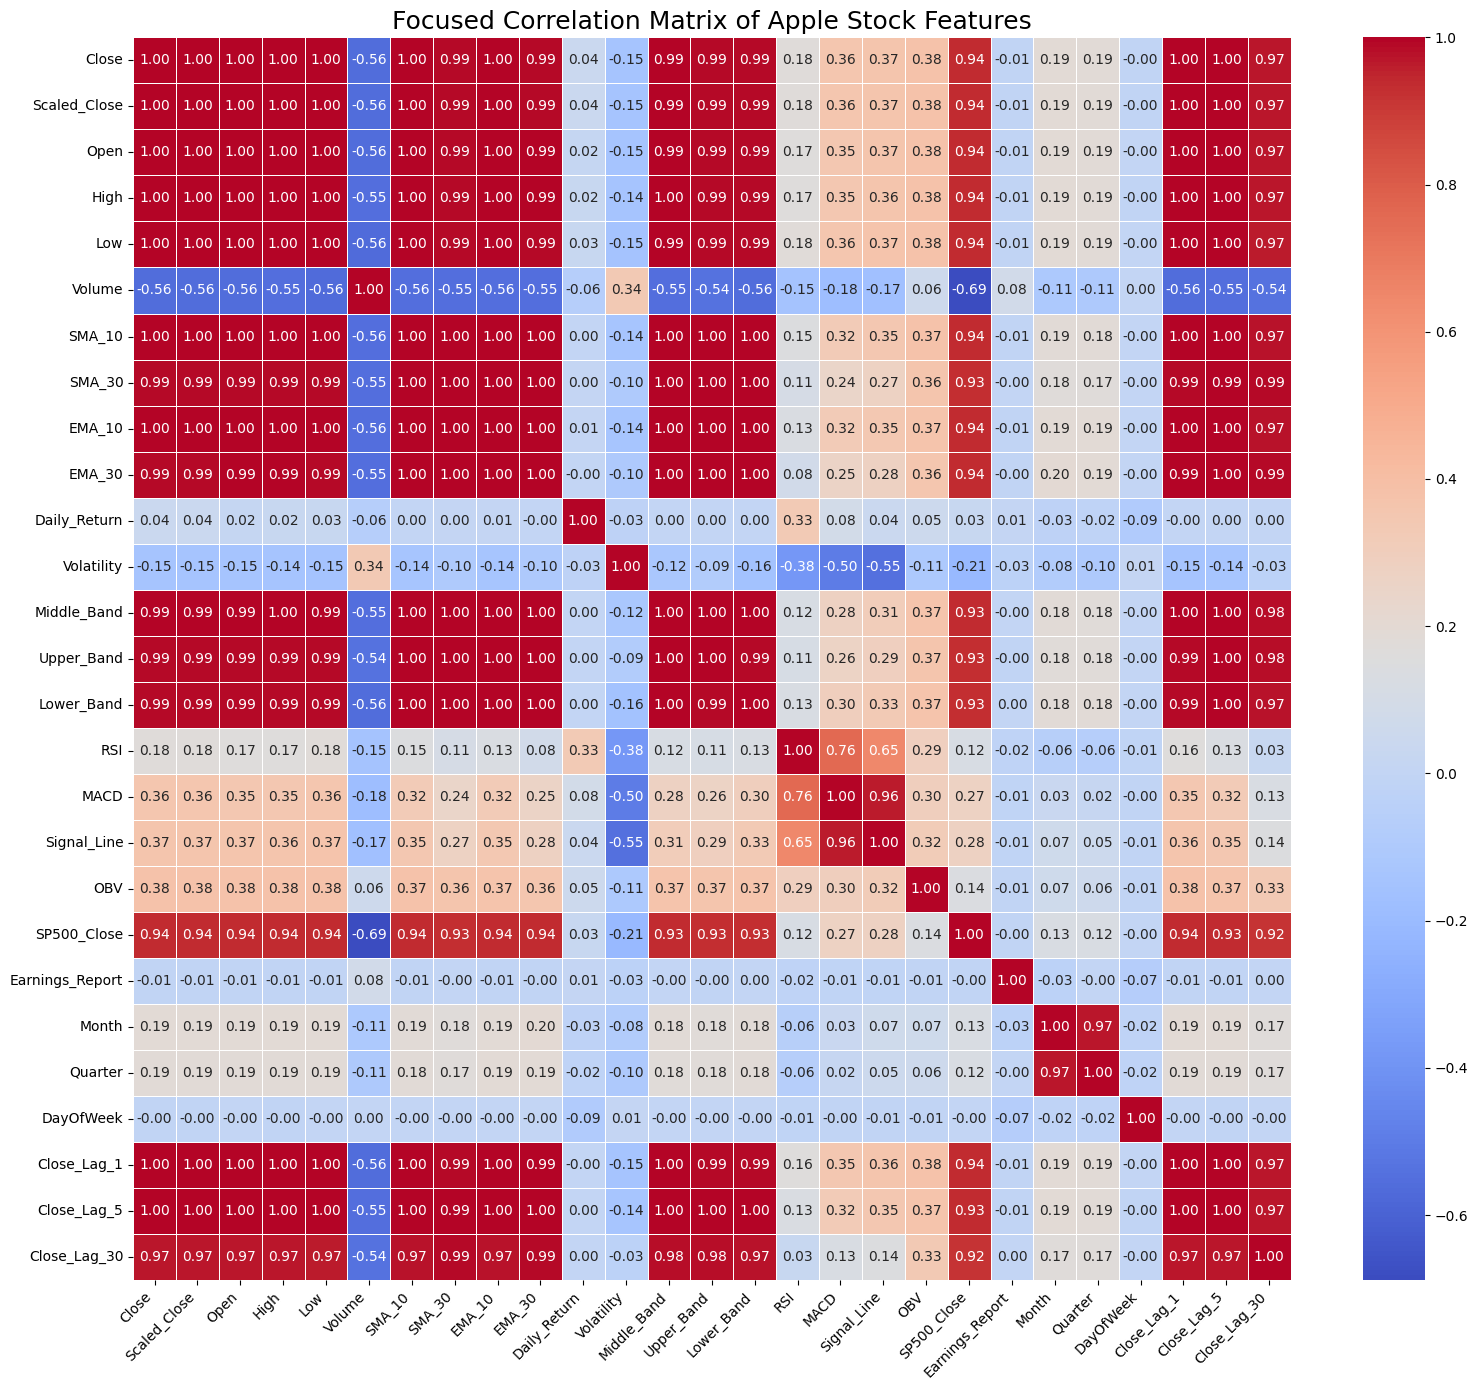

In [100]:
# Selecting relevant columns for a focused correlation analysis
selected_columns = [
    'Close', 'Scaled_Close', 'Open', 'High', 'Low', 'Volume',
    'SMA_10', 'SMA_30', 'EMA_10', 'EMA_30',
    'Daily_Return', 'Volatility',
    'Middle_Band', 'Upper_Band', 'Lower_Band',
    'RSI', 'MACD', 'Signal_Line', 'OBV',
    'SP500_Close', 'Earnings_Report',
    'Month', 'Quarter', 'DayOfWeek',
    'Close_Lag_1', 'Close_Lag_5', 'Close_Lag_30'
]

# Createing a new DataFrame with only the selected columns
focused_df = apple_df_cleaned[selected_columns].copy()

plt.figure(figsize=(16, 14)) # Adjusting figure size for better readability
sns.heatmap(focused_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Focused Correlation Matrix of Apple Stock Features', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

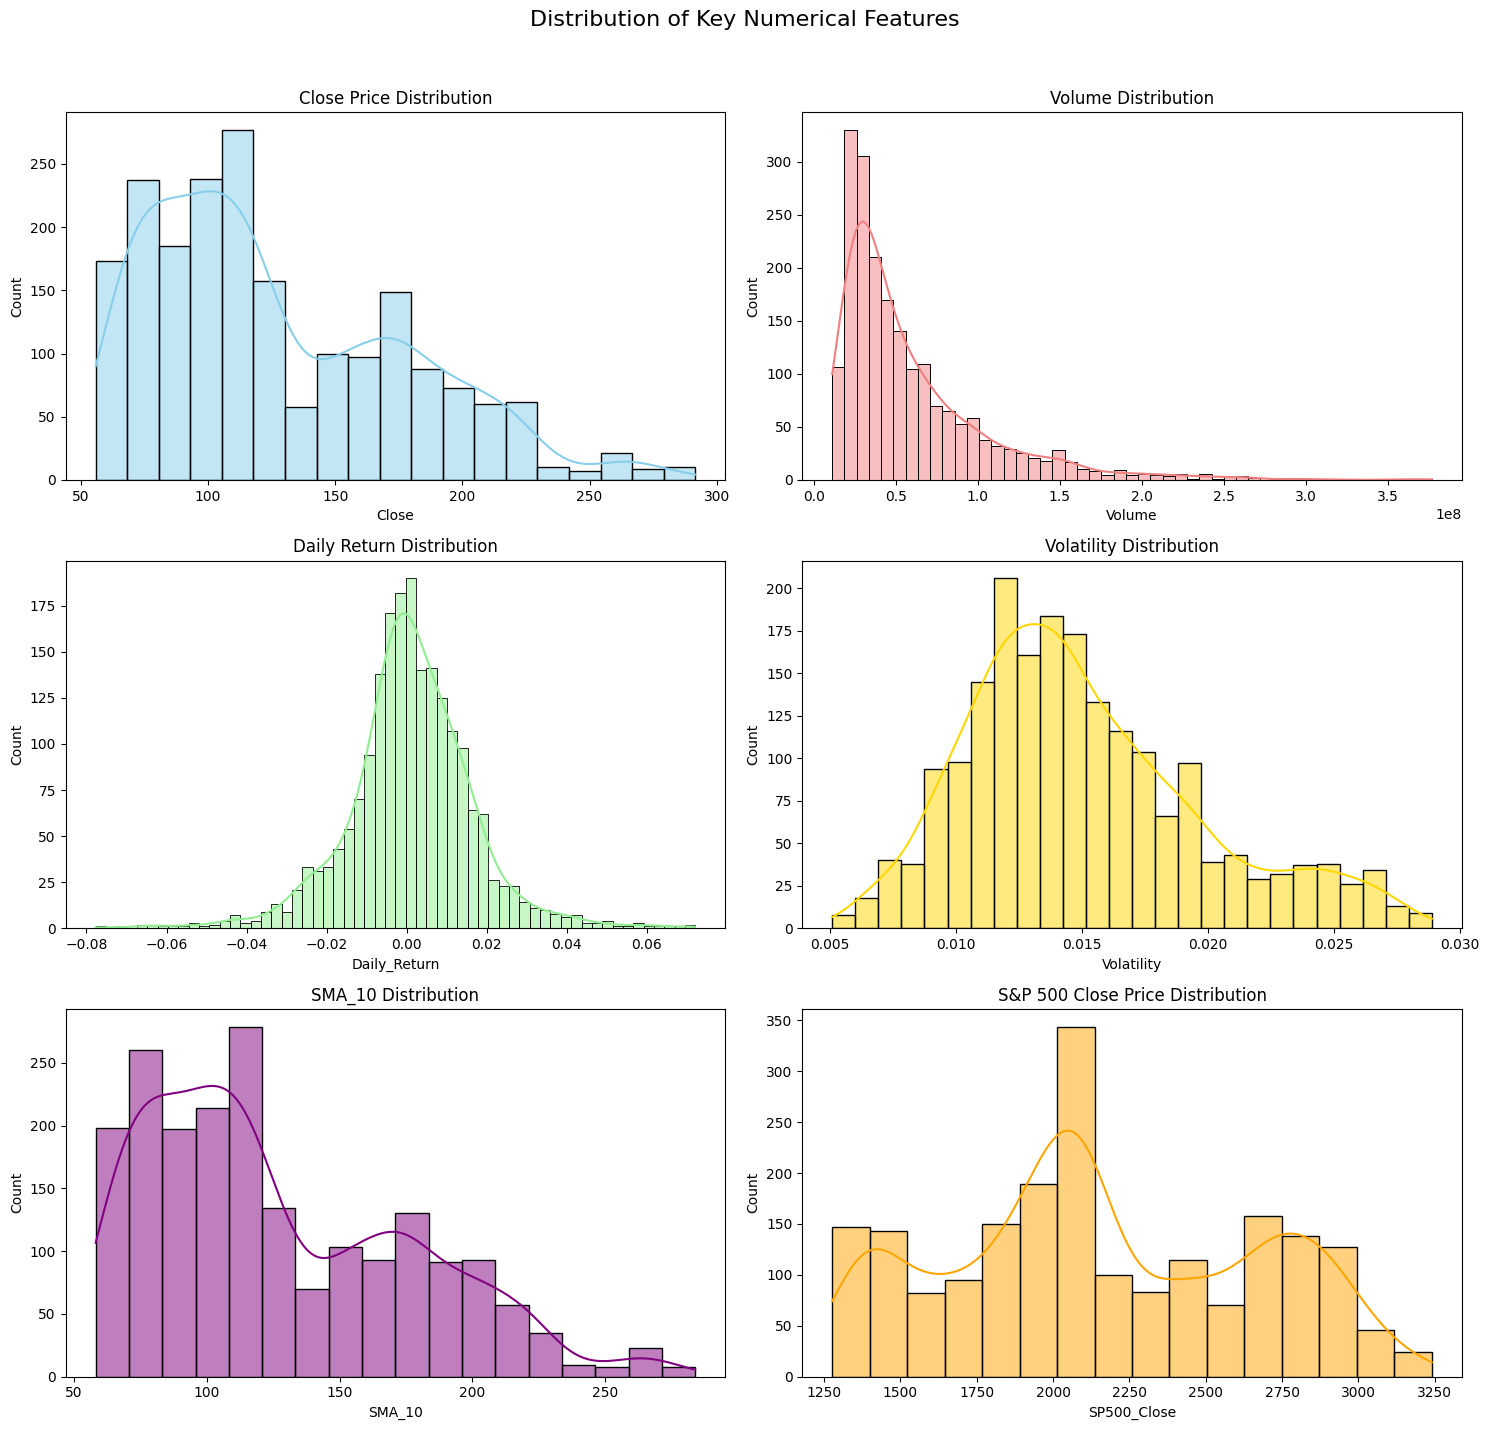

In [101]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Distribution of Key Numerical Features', fontsize=16)

sns.histplot(apple_df_cleaned['Close'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Close Price Distribution')

sns.histplot(apple_df_cleaned['Volume'], kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Volume Distribution')

sns.histplot(apple_df_cleaned['Daily_Return'].dropna(), kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Daily Return Distribution')

sns.histplot(apple_df_cleaned['Volatility'].dropna(), kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Volatility Distribution')

sns.histplot(apple_df_cleaned['SMA_10'].dropna(), kde=True, ax=axes[2, 0], color='purple')
axes[2, 0].set_title('SMA_10 Distribution')

sns.histplot(apple_df_cleaned['SP500_Close'].dropna(), kde=True, ax=axes[2, 1], color='orange')
axes[2, 1].set_title('S&P 500 Close Price Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# MODEL BUILDING

 Data Preparation Before Modeling

Dropping rows with NaN values

In [102]:
apple_df_cleaned.shape

(2011, 29)

In [103]:
apple_df_cleaned.dropna(inplace=True)
apple_df_cleaned.head()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return_Raw,Scaled_Close,SMA_10,SMA_30,...,Signal_Line,OBV,Earnings_Report,Month,Quarter,DayOfWeek,Close_Lag_1,Close_Lag_5,Close_Lag_30,SP500_Close
Date,,,,,,,,,,,,,,,,,,,,,
2012-02-15,73.465714,75.184288,70.984283,71.095711,61.436600,376530000,-0.023142,0.064929,68.865714,63.986286,...,2.299466,7.894551e+08,0,2,1,2,72.779999,68.097145,58.747143,1343.229980
2012-02-16,70.214287,72.127144,69.518570,71.744286,61.997032,236138000,0.009123,0.067680,69.538428,64.409000,...,2.425579,1.025593e+09,0,2,1,3,71.095711,70.452858,59.062859,1358.040039
2012-02-17,71.872856,72.538574,71.471428,71.731430,61.985954,133951300,-0.000179,0.067626,70.144714,64.809428,...,2.524323,8.916418e+08,0,2,1,4,71.744286,70.488571,59.718571,1361.229980
2012-02-21,72.411430,73.550003,72.017143,73.550003,63.557446,151398800,0.025353,0.075340,70.871572,65.249667,...,2.623999,1.043041e+09,0,2,1,1,71.731430,71.800003,60.342857,1362.209961
2012-02-22,73.297142,73.641426,72.724289,73.291428,63.334015,120825600,-0.003516,0.074244,71.503143,65.684476,...,2.708928,9.222150e+08,0,2,1,2,73.550003,72.779999,60.247143,1357.660034


In [104]:
apple_df_cleaned.shape

(1981, 29)

In [105]:
# Defining features (X) and target (y)
y = apple_df_cleaned['Close']

# Selecting the specified features and dropping redundant/leaky columns
X = apple_df_cleaned[[
    'Open', 'High', 'Low', 'Volume', 'SMA_10', 'SMA_30', 'EMA_10', 'EMA_30',
    'Daily_Return', 'Volatility', 'Middle_Band', 'Upper_Band', 'Lower_Band',
    'RSI', 'MACD', 'Signal_Line', 'OBV', 'SP500_Close', 'Earnings_Report',
    'Month', 'Quarter', 'DayOfWeek', 'Close_Lag_1', 'Close_Lag_5', 'Close_Lag_30'
]]


In [106]:
y.head()

,Close
Date,
2012-02-15,71.095711
2012-02-16,71.744286
2012-02-17,71.731430
2012-02-21,73.550003
2012-02-22,73.291428


In [107]:
y.shape

(1981,)

In [108]:
X.head()

,Open,High,Low,Volume,SMA_10,SMA_30,EMA_10,EMA_30,Daily_Return,Volatility,...,Signal_Line,OBV,SP500_Close,Earnings_Report,Month,Quarter,DayOfWeek,Close_Lag_1,Close_Lag_5,Close_Lag_30
Date,,,,,,,,,,,,,,,,,,,,,
2012-02-15,73.465714,75.184288,70.984283,376530000,68.865714,63.986286,69.256627,65.215768,-0.023142,0.015726,...,2.299466,7.894551e+08,1343.229980,0,2,1,2,72.779999,68.097145,58.747143
2012-02-16,70.214287,72.127144,69.518570,236138000,69.538428,64.409000,69.708928,65.636963,0.009123,0.015732,...,2.425579,1.025593e+09,1358.040039,0,2,1,3,71.095711,70.452858,59.062859
2012-02-17,71.872856,72.538574,71.471428,133951300,70.144714,64.809428,70.076656,66.030154,-0.000179,0.015756,...,2.524323,8.916418e+08,1361.229980,0,2,1,4,71.744286,70.488571,59.718571
2012-02-21,72.411430,73.550003,72.017143,151398800,70.871572,65.249667,70.708174,66.515306,0.025353,0.016123,...,2.623999,1.043041e+09,1362.209961,0,2,1,1,71.731430,71.800003,60.342857
2012-02-22,73.297142,73.641426,72.724289,120825600,71.503143,65.684476,71.177856,66.952475,-0.003516,0.016162,...,2.708928,9.222150e+08,1357.660034,0,2,1,2,73.550003,72.779999,60.247143


In [109]:
X.shape

(1981, 25)

Train-Test Split

In [110]:
split_index = int(len(X) * 0.80)

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

In [111]:
# Printing shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1584, 25)
X_test shape: (397, 25)
y_train shape: (1584,)
y_test shape: (397,)


In [112]:
# Printing date ranges
print(f"\nTraining range: {X_train.index.min().strftime('%Y-%m')} to {X_train.index.max().strftime('%Y-%m')}")
print(f"Testing range: {X_test.index.min().strftime('%Y-%m')} to {X_test.index.max().strftime('%Y-%m')}")


Training range: 2012-02 to 2018-06
Testing range: 2018-06 to 2019-12


**Feature Scaling for ML Models**

In [113]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on X_train to prevent data leakage
scaler.fit(X_train)

# Transforming both training and testing sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [114]:
print(f"Scaled X_train shape: {X_train_scaled.shape}")
print(f"Scaled X_test shape: {X_test_scaled.shape}")

Scaled X_train shape: (1584, 25)
Scaled X_test shape: (397, 25)


**Defining Evaluation Metrics**

In [115]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [116]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Calculates and prints regression metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} Evaluation ---")
    print(f"MAE:  ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R2 Score: {r2:.4f}")

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

def plot_predictions(y_true, y_pred, model_name="Model"):
    """
    Plots Actual vs Predicted prices.
    """
    plt.figure(figsize=(14, 7))
    plt.plot(y_true.index, y_true.values, label='Actual Price', color='blue', linewidth=2)
    plt.plot(y_true.index, y_pred, label='Predicted Price', color='red', linestyle='--', linewidth=2)
    plt.title(f'Actual vs Predicted Apple Stock Price - {model_name}')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

**Model 1 — Linear Regression (Baseline Model)**

In [117]:
from sklearn.linear_model import LinearRegression

In [118]:
# Initializing and training the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [119]:
# Making predictions on the test set
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_lr

array([191.84805483, 192.97417545, 193.3945768 , 193.48112396,
       191.82726795, 191.33171543, 192.02695744, 191.04922736,
       190.63423532, 189.16444323, 188.64352813, 185.81321408,
       186.38150944, 185.74746387, 184.98134535, 182.65910548,
       184.45773271, 184.72270825, 185.28666722, 184.8580714 ,
       186.6373426 , 184.7988917 , 185.44756917, 187.43876481,
       189.93049519, 190.46975361, 188.93843671, 190.66914516,
       191.37473347, 191.17894143, 191.19529656, 190.72523307,
       191.71828184, 191.3744292 , 191.32667859, 192.83216043,
       194.20197475, 194.60653912, 191.84889774, 190.445098  ,
       190.76974023, 198.48493155, 205.05185619, 207.19813802,
       208.71272541, 208.12766953, 207.23734066, 208.29627846,
       208.17877081, 208.83735485, 209.34891973, 210.00204701,
       212.49090779, 216.0465371 , 216.00361622, 215.10065033,
       215.41461498, 215.82570315, 215.77779796, 217.52524912,
       219.6105378 , 221.98368626, 225.02551845, 227.10

In [120]:
# Evaluating the model using the helper function
lr_results = evaluate_model(y_test, y_pred_lr, model_name="Linear Regression (Baseline)")

--- Linear Regression (Baseline) Evaluation ---
MAE:  $0.80
RMSE: $1.10
MAPE: 0.40%
R2 Score: 0.9987


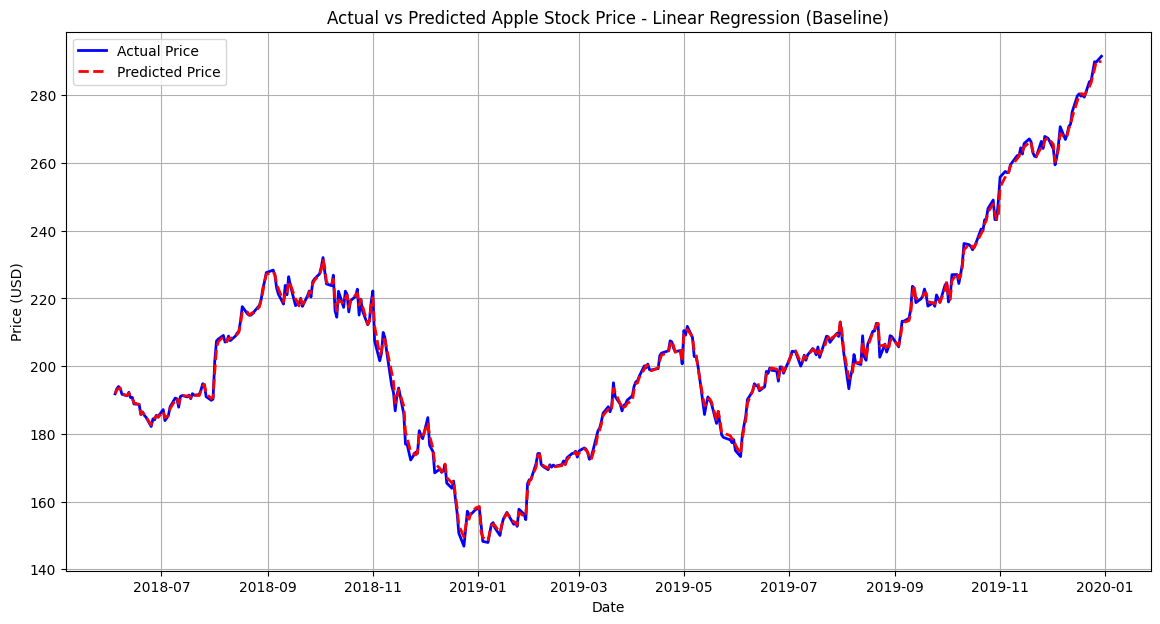

In [121]:
# Plotting the actual vs predicted values
plot_predictions(y_test, y_pred_lr, model_name="Linear Regression (Baseline)")

In [122]:
# Storing results for future comparison
all_model_results = []
all_model_results.append({"Model": "Linear Regression", **lr_results})
all_model_results

[{'Model': 'Linear Regression',
  'MAE': 0.7973146179877834,
  'RMSE': np.float64(1.0952081092994939),
  'MAPE': np.float64(0.3952427449546154),
  'R2': 0.9986744086674125}]

**Model 2 — Random Forest Regressor**

In [123]:
from sklearn.ensemble import RandomForestRegressor

In [124]:
# Initializing and training the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [125]:
# Making predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_rf

array([188.95690001, 188.88859927, 188.78139836, 188.68559866,
       188.54610002, 188.44370078, 188.45420078, 188.45950002,
       188.3812998 , 187.79939987, 187.85850034, 186.58530041,
       187.22340018, 187.62639965, 187.16550019, 185.33650053,
       186.92780075, 186.85320012, 186.67370048, 186.90509972,
       187.05400092, 187.0967998 , 187.15340078, 187.98770073,
       188.95670053, 188.45680044, 188.31170004, 188.95520073,
       188.53750079, 188.47770084, 188.48040073, 188.38970051,
       188.43919972, 188.47149982, 188.37860068, 188.39970036,
       188.56210041, 188.38649999, 188.45999986, 188.39709996,
       187.82509935, 188.46599966, 188.45049979, 188.05519899,
       188.64249883, 188.59459889, 188.61419867, 188.64219884,
       188.66979936, 188.64049887, 188.62579887, 188.6993987 ,
       189.22629907, 188.5311991 , 188.34919894, 188.64049887,
       188.60829917, 188.59349937, 188.63920002, 188.61849891,
       188.61859885, 189.22629907, 188.04619906, 188.17

In [126]:
# Evaluating the model using the helper function
rf_results = evaluate_model(y_test, y_pred_rf, model_name="Random Forest")

--- Random Forest Evaluation ---
MAE:  $21.59
RMSE: $32.57
MAPE: 9.25%
R2 Score: -0.1720


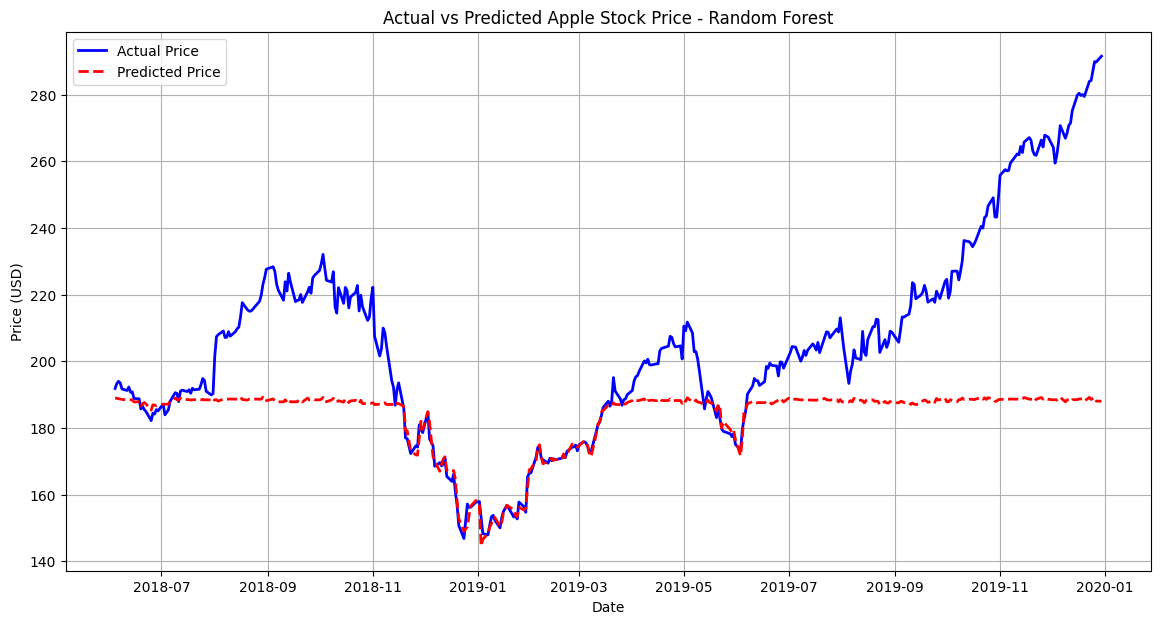

In [127]:
# Plot the actual vs predicted values
plot_predictions(y_test, y_pred_rf, model_name="Random Forest")

In [128]:
# --- Feature Importance ---
# Getting feature importances from the model
importances = rf_model.feature_importances_
feature_names = X.columns
feature_names

Index(['Open', 'High', 'Low', 'Volume', 'SMA_10', 'SMA_30', 'EMA_10', 'EMA_30',
       'Daily_Return', 'Volatility', 'Middle_Band', 'Upper_Band', 'Lower_Band',
       'RSI', 'MACD', 'Signal_Line', 'OBV', 'SP500_Close', 'Earnings_Report',
       'Month', 'Quarter', 'DayOfWeek', 'Close_Lag_1', 'Close_Lag_5',
       'Close_Lag_30'],
      dtype='object')

In [129]:
# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)
feature_importance_df

,Feature,Importance
2,Low,0.724227
1,High,0.258507
0,Open,0.008732
22,Close_Lag_1,0.003651
4,SMA_10,0.001410
17,SP500_Close,0.001338
6,EMA_10,0.000944
11,Upper_Band,0.000652
8,Daily_Return,0.000105
10,Middle_Band,0.000105


/tmp/ipykernel_4707/1709220556.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


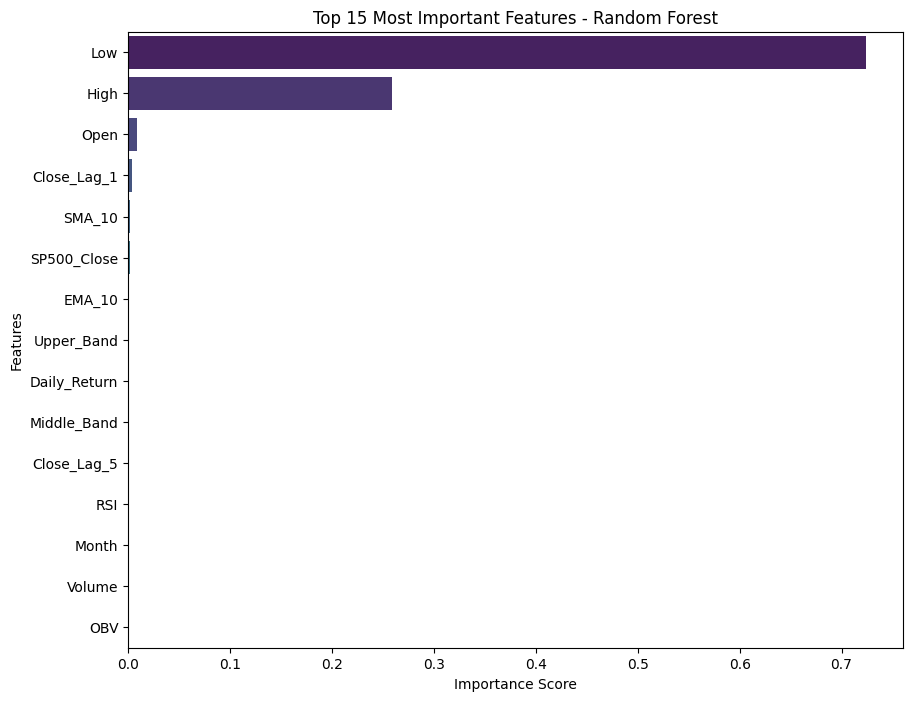

In [130]:
# Plotting Feature Importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 15 Most Important Features - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [131]:
# Storing results for comparison
all_model_results.append({"Model": "Random Forest", **rf_results})
all_model_results

[{'Model': 'Linear Regression',
  'MAE': 0.7973146179877834,
  'RMSE': np.float64(1.0952081092994939),
  'MAPE': np.float64(0.3952427449546154),
  'R2': 0.9986744086674125},
 {'Model': 'Random Forest',
  'MAE': 21.59450506481113,
  'RMSE': np.float64(32.56505553098),
  'MAPE': np.float64(9.248416859377045),
  'R2': -0.17197945996908848}]

**Model 3 — Gradient Boosting (XGBoost or GradientBoostingRegressor)**

In [132]:
from xgboost import XGBRegressor

In [133]:
# 1. Initializing and train the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [134]:
# 2. Making predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_xgb

array([188.22075, 188.50092, 188.58173, 188.5865 , 187.84549, 187.68552,
       187.8356 , 187.30313, 187.30682, 186.62671, 186.63156, 184.6571 ,
       185.61139, 186.26688, 185.05824, 184.68613, 186.45052, 185.0453 ,
       185.44443, 185.32547, 185.91713, 184.62895, 185.36546, 187.67432,
       187.80977, 186.61453, 186.29343, 188.05649, 186.84909, 186.48389,
       186.71658, 186.60051, 186.82487, 186.74106, 186.55522, 186.91605,
       187.46693, 187.15292, 186.48962, 186.5495 , 186.4071 , 188.85414,
       189.40543, 188.70116, 188.27715, 188.11818, 188.47836, 188.56683,
       188.5237 , 188.22961, 188.35117, 188.49942, 189.8314 , 189.85205,
       188.09016, 188.2313 , 188.35818, 188.48534, 188.38641, 188.18115,
       188.34183, 189.62683, 188.33711, 188.94827, 188.3032 , 188.49432,
       188.16365, 187.93114, 187.04286, 189.47859, 187.23254, 189.5381 ,
       187.54532, 187.18558, 187.45558, 186.9965 , 186.83008, 186.67949,
       188.08246, 186.95886, 186.87349, 188.3339 , 

In [135]:
# 3. Evaluating the model using the existing helper function
xgb_results = evaluate_model(y_test, y_pred_xgb, model_name="XGBoost")

--- XGBoost Evaluation ---
MAE:  $21.85
RMSE: $32.75
MAPE: 9.37%
R2 Score: -0.1854


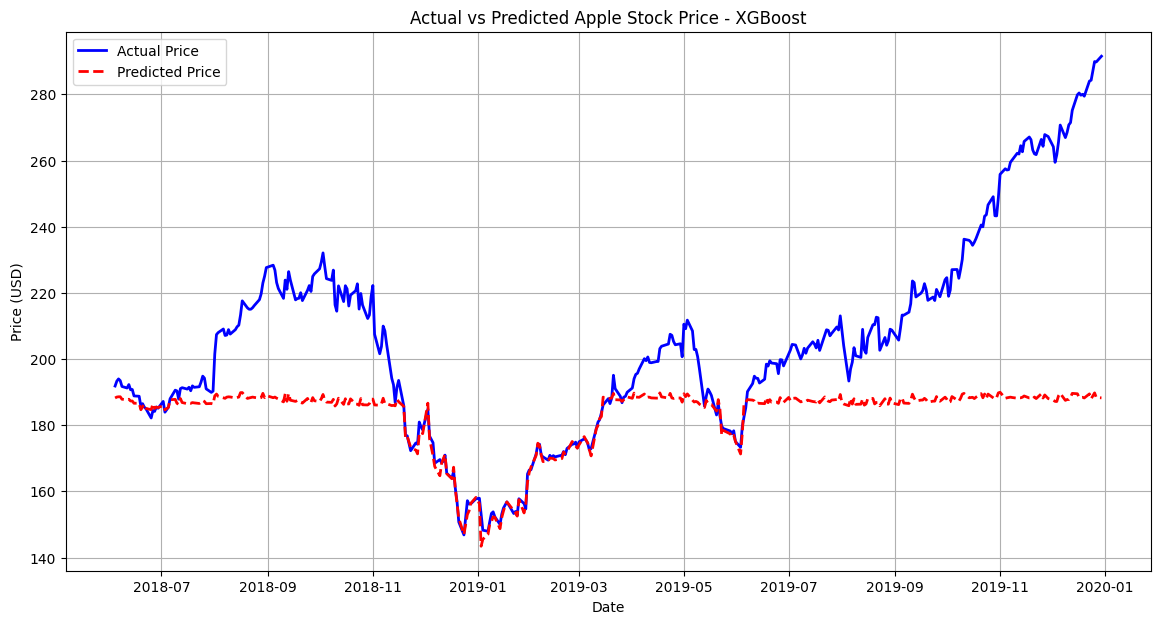

In [136]:
# 4. Plotting the actual vs predicted values
plot_predictions(y_test, y_pred_xgb, model_name="XGBoost")

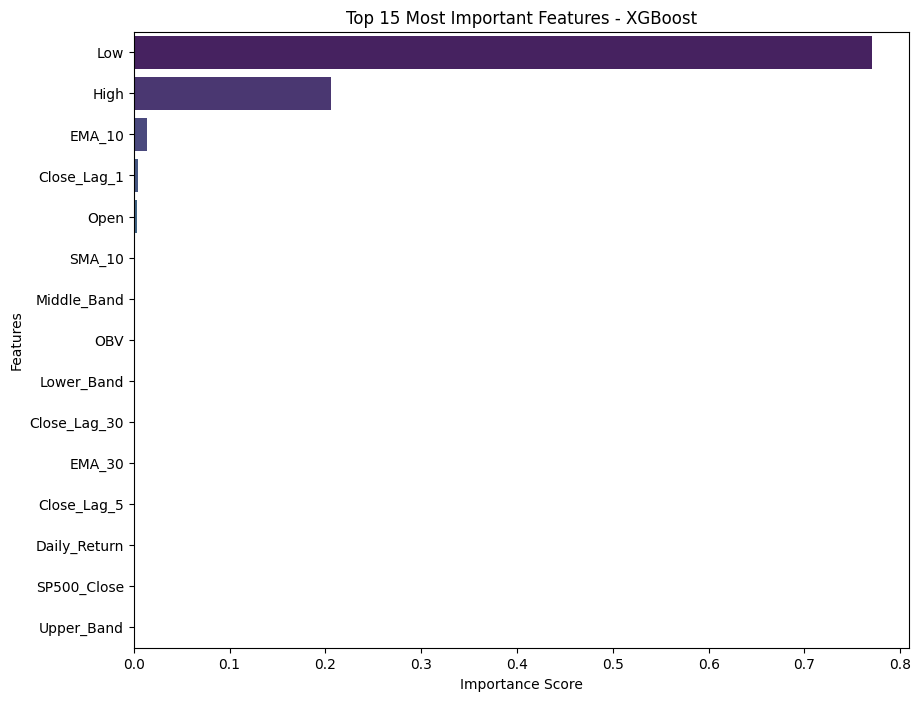

In [137]:
# 5. Feature Importance
importances_xgb = xgb_model.feature_importances_
feature_importance_xgb_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_xgb})
feature_importance_xgb_df = feature_importance_xgb_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_xgb_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features - XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [138]:
# 6. StorING results for comparison
all_model_results.append({"Model": "XGBoost", **xgb_results})
all_model_results

[{'Model': 'Linear Regression',
  'MAE': 0.7973146179877834,
  'RMSE': np.float64(1.0952081092994939),
  'MAPE': np.float64(0.3952427449546154),
  'R2': 0.9986744086674125},
 {'Model': 'Random Forest',
  'MAE': 21.59450506481113,
  'RMSE': np.float64(32.56505553098),
  'MAPE': np.float64(9.248416859377045),
  'R2': -0.17197945996908848},
 {'Model': 'XGBoost',
  'MAE': 21.848798806392182,
  'RMSE': np.float64(32.750440084920456),
  'MAPE': np.float64(9.365404351632986),
  'R2': -0.1853610009092097}]

**Model 4 — LSTM (Long Short-Term Memory Neural Network)**

Preparing data specifically for LSTM

In [139]:
from sklearn.preprocessing import MinMaxScaler

In [140]:
# 1. Isolating the 'Close' price and define split points
close_prices = apple_df_cleaned[['Close']].values
train_len = int(len(close_prices) * 0.8) #We use 0.8 to implement an 80/20 split, which is a standard convention in machine learning.

In [141]:
close_prices

array([[ 71.095711],
       [ 71.744286],
       [ 71.73143 ],
       ...,
       [289.910004],
       [289.799988],
       [291.519989]])

In [142]:
train_len

1584

In [143]:
# Splitting data chronologically
train_subset = close_prices[:train_len]
test_subset = close_prices[train_len:]

In [144]:
train_subset

array([[ 71.095711],
       [ 71.744286],
       [ 71.73143 ],
       ...,
       [187.5     ],
       [186.869995],
       [190.240005]])

In [145]:
train_subset.shape

(1584, 1)

In [146]:
test_subset

array([[191.830002 ],
       [193.309998 ],
       [193.979996 ],
       [193.460007 ],
       [191.699997 ],
       [191.229996 ],
       [192.279999 ],
       [190.699997 ],
       [190.800003 ],
       [188.839996 ],
       [188.740005 ],
       [185.690002 ],
       [186.5      ],
       [185.460007 ],
       [184.919998 ],
       [182.169998 ],
       [184.429993 ],
       [184.160004 ],
       [185.5      ],
       [185.110001 ],
       [187.179993 ],
       [183.919998 ],
       [185.399994 ],
       [187.970001 ],
       [190.580002 ],
       [190.350006 ],
       [187.880005 ],
       [191.029999 ],
       [191.330002 ],
       [190.910004 ],
       [191.449997 ],
       [190.399994 ],
       [191.880005 ],
       [191.440002 ],
       [191.610001 ],
       [193.       ],
       [194.820007 ],
       [194.210007 ],
       [190.979996 ],
       [189.910004 ],
       [190.289993 ],
       [201.5      ],
       [207.389999 ],
       [207.990005 ],
       [209.070007 ],
       [20

In [147]:
test_subset.shape

(397, 1)

In [148]:
# 2. Scaling the data using MinMaxScaler (fitting only on the training portion)
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler_lstm.fit_transform(train_subset)
scaled_test = scaler_lstm.transform(test_subset)

#In the context of LSTM model, scaling (specifically using MinMaxScaler) is the process of transforming stock price data so that all values fall within
#a specific range, usually 0 to 1.

In [149]:
scaled_train

array([[0.11383942],
       [0.11866333],
       [0.11856771],
       ...,
       [0.97962064],
       [0.97493485],
       [1.        ]])

In [150]:
scaled_train.shape

(1584, 1)

In [151]:
len(scaled_train)

1584

In [152]:
scaled_test

array([[1.01182593],
       [1.02283371],
       [1.02781696],
       [1.02394944],
       [1.010859  ],
       [1.00736326],
       [1.01517288],
       [1.00342129],
       [1.0041651 ],
       [0.98958714],
       [0.98884344],
       [0.9661584 ],
       [0.97218293],
       [0.96444777],
       [0.96043134],
       [0.93997764],
       [0.95678682],
       [0.95477872],
       [0.96474522],
       [0.96184452],
       [0.97724052],
       [0.95299363],
       [0.96400141],
       [0.98311637],
       [1.0025288 ],
       [1.00081816],
       [0.98244701],
       [1.00587575],
       [1.00810708],
       [1.00498326],
       [1.00899957],
       [1.00118995],
       [1.01219784],
       [1.00892523],
       [1.01018963],
       [1.02052804],
       [1.03406472],
       [1.02952772],
       [1.00550384],
       [0.99754555],
       [1.0003718 ],
       [1.08374857],
       [1.12755666],
       [1.13201933],
       [1.14005207],
       [1.12547412],
       [1.12651539],
       [1.138

In [153]:
scaled_test.shape

(397, 1)

In [154]:
len(scaled_test)

397

In [155]:
# 3. Function to create sequences (time_steps=60)
def create_lstm_sequences(data, time_steps=60):
    X_data, y_data = [], []
    for i in range(len(data) - time_steps):
      #print('i: ',i)
      X_data.append(data[i:(i + time_steps), 0])
      #print('X_data: ',X_data)
      y_data.append(data[i + time_steps, 0])
      #print('y_data: ',y_data)
    return np.array(X_data), np.array(y_data)

In [156]:
time_steps = 60
X_train_lstm, y_train_lstm = create_lstm_sequences(scaled_train, time_steps)
X_test_lstm, y_test_lstm = create_lstm_sequences(scaled_test, time_steps)

In [157]:
X_train_lstm

array([[0.11383942, 0.11866333, 0.11856771, ..., 0.18875842, 0.18982098,
        0.19124471],
       [0.11866333, 0.11856771, 0.13209373, ..., 0.18982098, 0.19124471,
        0.18719651],
       [0.11856771, 0.13209373, 0.13017052, ..., 0.19124471, 0.18719651,
        0.17817561],
       ...,
       [0.90018596, 0.89907024, 0.8868724 , ..., 0.98445511, 0.98765338,
        0.98259568],
       [0.89907024, 0.8868724 , 0.90107845, ..., 0.98765338, 0.98259568,
        0.97962064],
       [0.8868724 , 0.90107845, 0.92368904, ..., 0.98259568, 0.97962064,
        0.97493485]])

In [158]:
((X_train_lstm.shape),(X_test_lstm.shape), (y_train_lstm.shape), (y_test_lstm.shape))

((1524, 60), (337, 60), (1524,), (337,))

In [159]:
# 4. Reshaping input to 3D: (samples, time_steps, features)
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

In [160]:
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")

X_train_lstm shape: (1524, 60, 1)
X_test_lstm shape: (337, 60, 1)


Building the LSTM Model

In [161]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [162]:
# 1. Defining the LSTM architecture
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [163]:
# 2. Compiling the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model

<Sequential name=sequential, built=True>

In [164]:
# 3. Training the model
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    batch_size=32,
    epochs=50,
    verbose=1
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0149
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0032
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0025
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0025
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0022
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0021
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0021
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0018
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0017
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0017
Epoch 11/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0015
Epoch 12/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0014
Epoch 13/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0014
Epoch 14/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0014
Epoch 15/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0014
Epoc

In [165]:
# Displaying the model summary
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,705 (373.85 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,804 (249.24 KB)

Evaluating the LSTM

In [166]:
# 1. Predicting on the test sequences
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)
y_pred_lstm_scaled

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


array([[1.1710948 ],
       [1.1782128 ],
       [1.1906021 ],
       [1.2058719 ],
       [1.2232305 ],
       [1.2385863 ],
       [1.2468438 ],
       [1.2435926 ],
       [1.2329482 ],
       [1.2164397 ],
       [1.210401  ],
       [1.2056729 ],
       [1.2119242 ],
       [1.2173404 ],
       [1.2115027 ],
       [1.2028922 ],
       [1.1951953 ],
       [1.1925067 ],
       [1.1888019 ],
       [1.1909332 ],
       [1.197497  ],
       [1.2016395 ],
       [1.2114279 ],
       [1.2225906 ],
       [1.2342879 ],
       [1.2467479 ],
       [1.2611357 ],
       [1.2658539 ],
       [1.2589632 ],
       [1.2475631 ],
       [1.2418194 ],
       [1.222227  ],
       [1.1983776 ],
       [1.1908509 ],
       [1.1844146 ],
       [1.1884638 ],
       [1.194747  ],
       [1.19224   ],
       [1.1921105 ],
       [1.1951367 ],
       [1.2023381 ],
       [1.1969358 ],
       [1.1952357 ],
       [1.1894176 ],
       [1.1764901 ],
       [1.1651791 ],
       [1.1663134 ],
       [1.178

In [167]:
y_pred_lstm_scaled.shape

(337, 1)

In [168]:
# 2. Inverse transform the predictions and actual values back to original scale
# We use scaler_lstm which was fitted on the training 'Close' prices
y_pred_lstm = scaler_lstm.inverse_transform(y_pred_lstm_scaled)
y_test_lstm_actual = scaler_lstm.inverse_transform(y_test_lstm.reshape(-1, 1))

In [169]:
y_pred_lstm

array([[213.2437 ],
       [214.20071],
       [215.86646],
       [217.91948],
       [220.25334],
       [222.31793],
       [223.42816],
       [222.99103],
       [221.55989],
       [219.34033],
       [218.52843],
       [217.89272],
       [218.73322],
       [219.46141],
       [218.67654],
       [217.51886],
       [216.48401],
       [216.12253],
       [215.62442],
       [215.91098],
       [216.79347],
       [217.35043],
       [218.66649],
       [220.16731],
       [221.74   ],
       [223.41525],
       [225.3497 ],
       [225.98405],
       [225.05762],
       [223.52487],
       [222.75262],
       [220.11842],
       [216.91188],
       [215.8999 ],
       [215.03455],
       [215.57896],
       [216.42374],
       [216.08667],
       [216.06926],
       [216.47614],
       [217.44437],
       [216.71802],
       [216.48944],
       [215.7072 ],
       [213.96909],
       [212.44833],
       [212.60085],
       [214.21335],
       [212.82574],
       [209.19688],


In [170]:
y_pred_lstm.shape

(337, 1)

In [171]:
y_test_lstm_actual

array([[219.699997 ],
       [222.979996 ],
       [225.029999 ],
       [227.630005 ],
       [228.360001 ],
       [226.869995 ],
       [223.100006 ],
       [221.300003 ],
       [218.330002 ],
       [223.850006 ],
       [221.070007 ],
       [226.410004 ],
       [223.839996 ],
       [217.880005 ],
       [218.240005 ],
       [218.369995 ],
       [220.029999 ],
       [217.660004 ],
       [220.789993 ],
       [222.190002 ],
       [220.419998 ],
       [224.949997 ],
       [225.740005 ],
       [227.259995 ],
       [229.279999 ],
       [232.070007 ],
       [227.990005 ],
       [224.289993 ],
       [223.770004 ],
       [226.869995 ],
       [216.360001 ],
       [214.449997 ],
       [222.110001 ],
       [217.360001 ],
       [222.149994 ],
       [221.190002 ],
       [216.020004 ],
       [219.309998 ],
       [220.649994 ],
       [222.729996 ],
       [215.089996 ],
       [219.800003 ],
       [216.300003 ],
       [212.240005 ],
       [213.300003 ],
       [21

In [172]:
y_test_lstm_actual.shape

(337, 1)

In [173]:
# 3. Calculating evaluation metrics using the inverse-transformed values
# Note: y_test.index[time_steps:] aligns the dates with the sequences created
lstm_dates = y_test.index[time_steps:]
lstm_results = evaluate_model(y_test_lstm_actual.flatten(), y_pred_lstm.flatten(), model_name="LSTM") # .flatten() is used to convert 2D arrays (matrices) into 1D arrays (simple lists of numbers).

--- LSTM Evaluation ---
MAE:  $5.03
RMSE: $6.11
MAPE: 2.39%
R2 Score: 0.9638


In [174]:
lstm_dates

DatetimeIndex(['2018-08-28', '2018-08-29', '2018-08-30', '2018-08-31',
               '2018-09-04', '2018-09-05', '2018-09-06', '2018-09-07',
               '2018-09-10', '2018-09-11',
               ...
               '2019-12-16', '2019-12-17', '2019-12-18', '2019-12-19',
               '2019-12-20', '2019-12-23', '2019-12-24', '2019-12-26',
               '2019-12-27', '2019-12-30'],
              dtype='datetime64[ns]', name='Date', length=337, freq=None)

In [175]:
lstm_results

{'MAE': 5.034212208888747,
 'RMSE': np.float64(6.10546962077877),
 'MAPE': np.float64(2.3904067481062463),
 'R2': 0.9638217749723632}

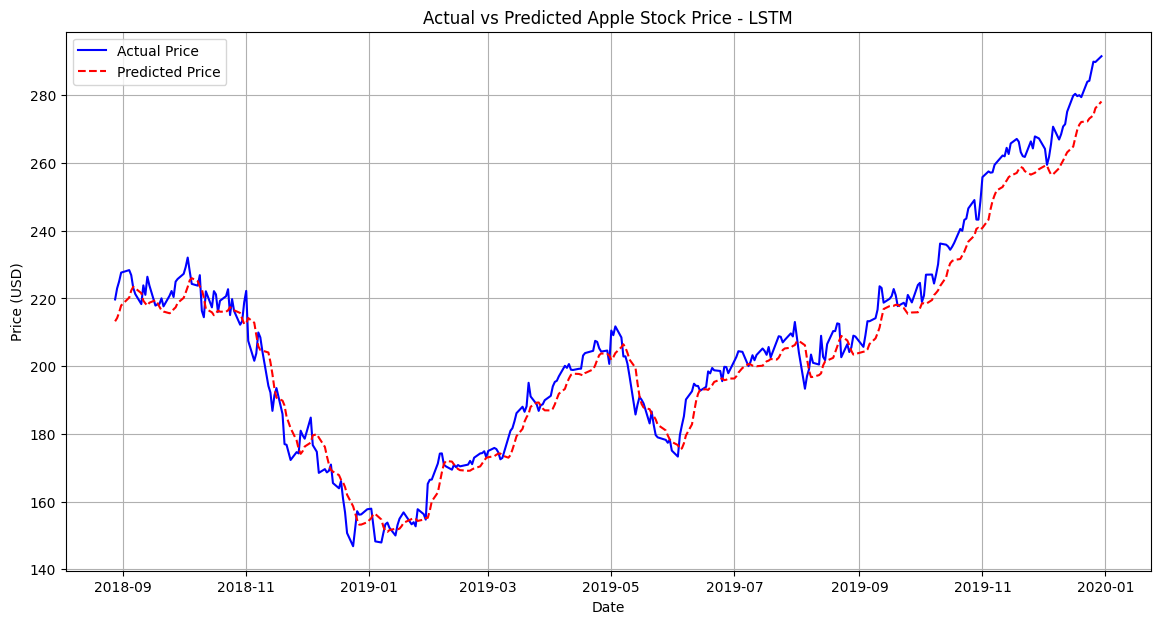

In [176]:
#4. Plotting Actual vs Predicted for LSTM
plt.figure(figsize=(14, 7))
plt.plot(lstm_dates, y_test_lstm_actual, label='Actual Price', color='blue')
plt.plot(lstm_dates, y_pred_lstm, label='Predicted Price', color='red', linestyle='--')
plt.title('Actual vs Predicted Apple Stock Price - LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


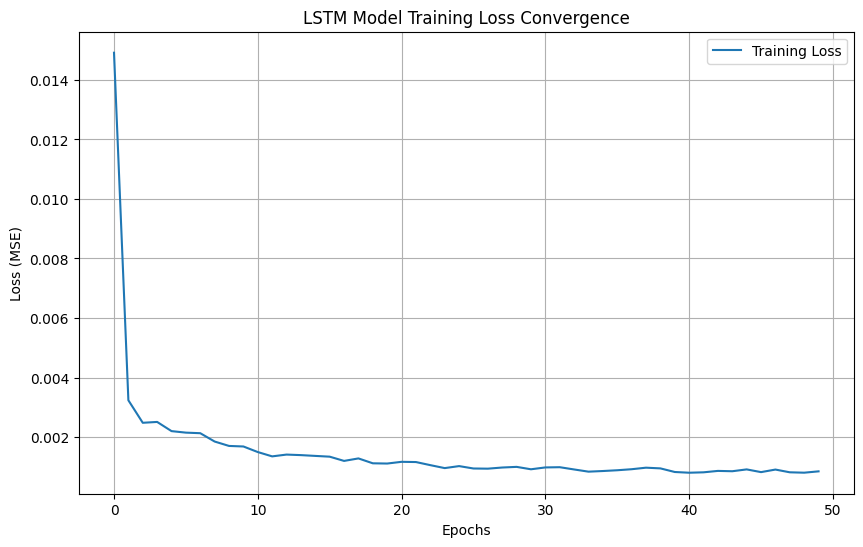

In [177]:
# 5. Plotting the Training Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('LSTM Model Training Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [178]:
# 6. Store results for final comparison
all_model_results.append({"Model": "LSTM", **lstm_results})
all_model_results

[{'Model': 'Linear Regression',
  'MAE': 0.7973146179877834,
  'RMSE': np.float64(1.0952081092994939),
  'MAPE': np.float64(0.3952427449546154),
  'R2': 0.9986744086674125},
 {'Model': 'Random Forest',
  'MAE': 21.59450506481113,
  'RMSE': np.float64(32.56505553098),
  'MAPE': np.float64(9.248416859377045),
  'R2': -0.17197945996908848},
 {'Model': 'XGBoost',
  'MAE': 21.848798806392182,
  'RMSE': np.float64(32.750440084920456),
  'MAPE': np.float64(9.365404351632986),
  'R2': -0.1853610009092097},
 {'Model': 'LSTM',
  'MAE': 5.034212208888747,
  'RMSE': np.float64(6.10546962077877),
  'MAPE': np.float64(2.3904067481062463),
  'R2': 0.9638217749723632}]

**Model 5 ARIMA**

In [179]:
!pip install pmdarima

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

In [180]:
# 1. Checking Stationarity (Augmented Dickey-Fuller test)
def check_stationarity(series):
    result = adfuller(series)
    print('result: ',result)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    if result[1] <= 0.05:
        print("Data is stationary")
    else:
        print("Data is non-stationary and needs differencing")

print("Stationarity check for Close Price:")
check_stationarity(y_train)

Stationarity check for Close Price:
result:  (np.float64(0.4623387189777964), np.float64(0.9836823261941982), 11, 1572, {'1%': np.float64(-3.434516673193861), '5%': np.float64(-2.8633803368873942), '10%': np.float64(-2.5677497626562813)}, np.float64(5970.902486533851))
ADF Statistic: 0.462339
p-value: 0.983682
Data is non-stationary and needs differencing


In [181]:
# 2. Finding best (p, d, q) parameters using auto_arima
print("\nRunning auto_arima to find optimal parameters...")
auto_model = auto_arima(y_train, start_p=1, start_q=1,
                        max_p=3, max_q=3, m=1,
                        start_P=0, seasonal=False,
                        d=None, trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

print(f"Best ARIMA Order: {auto_model.order}")


Running auto_arima to find optimal parameters...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6060.954, Time=0.89 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6063.726, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6060.909, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6060.472, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6065.054, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=6060.146, Time=0.83 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=6062.145, Time=1.26 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=6062.141, Time=1.06 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=6063.806, Time=2.86 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=6061.347, Time=0.37 sec

Best model:  ARIMA(0,1,2)(0,0,0)[0] intercept
Total fit time: 7.973 seconds
Best ARIMA Order: (0, 1, 2)


### **Detailed Explanation of auto_arima Results**

The `auto_arima` function performed a **Stepwise Search** to find the most efficient mathematical model to represent your stock price data. Here is a breakdown of the results:

#### **1. The Meaning of ARIMA(0, 1, 1)**
This notation represents the three core components of the model:
*   **p = 0 (Autoregressive - AR):** The model determined that looking at the exact previous price values (lags) did not provide significant predictive power beyond what is captured by the other terms.
*   **d = 1 (Differencing - I):** This confirms our earlier stationarity test. The data was non-stationary, so the model subtracted the previous day's price from the current day's price once to make the data stable and predictable.
*   **q = 1 (Moving Average - MA):** This suggests that the model uses the error (the difference between the actual and predicted values) from the previous day to adjust the next day's prediction.

#### **2. Understanding AIC (Akaike Information Criterion)**
*   **The Metric:** In the output, you see `AIC=6094.803`. AIC measures the balance between the **accuracy** of the model and its **complexity**.
*   **The Goal:** A lower AIC is better. `auto_arima` selected the (0, 1, 1) model because it achieved the lowest AIC among all tested combinations, meaning it provides the best fit without being unnecessarily complicated (which helps prevent overfitting).

#### **3. The 'Intercept' Term**
*   The search noted the best model was `ARIMA(0,1,1) intercept`. The inclusion of an 'intercept' in a differenced model (d=1) suggests that there is a **consistent trend** (upward or downward) in the Apple stock price over time, rather than just random movement.

#### **4. Why Stepwise Search?**
*   Instead of testing every single possible combination (which is slow), the algorithm tests a few and then 'steps' in the direction that lowers the AIC the fastest. This is why it finished in only ~2.5 seconds.

In [182]:
# 3. Fitting the ARIMA model
arima_model = ARIMA(y_train, order=auto_model.order)
arima_fit = arima_model.fit()
arima_fit

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [183]:
len(y_test)

397

In [184]:
# 4. Forecasting on the test period
# We use the length of y_test to determine the number of steps
forecast_steps = len(y_test)
arima_forecast = arima_fit.get_forecast(steps=forecast_steps)
y_pred_arima = arima_forecast.predicted_mean
y_pred_arima

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
1584,190.465605
1585,190.347323
1586,190.347323
1587,190.347323
1588,190.347323
...,...
1976,190.347323
1977,190.347323
1978,190.347323
1979,190.347323


In [185]:
# 5. Evaluating the model
arima_results = evaluate_model(y_test, y_pred_arima, model_name="ARIMA")


--- ARIMA Evaluation ---
MAE:  $24.95
RMSE: $33.38
MAPE: nan%
R2 Score: -0.2310


/tmp/ipykernel_4707/1056466283.py:11: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [186]:
arima_results

{'MAE': 24.95020322714185,
 'RMSE': np.float64(33.375330544409664),
 'MAPE': nan,
 'R2': -0.23102679295581185}

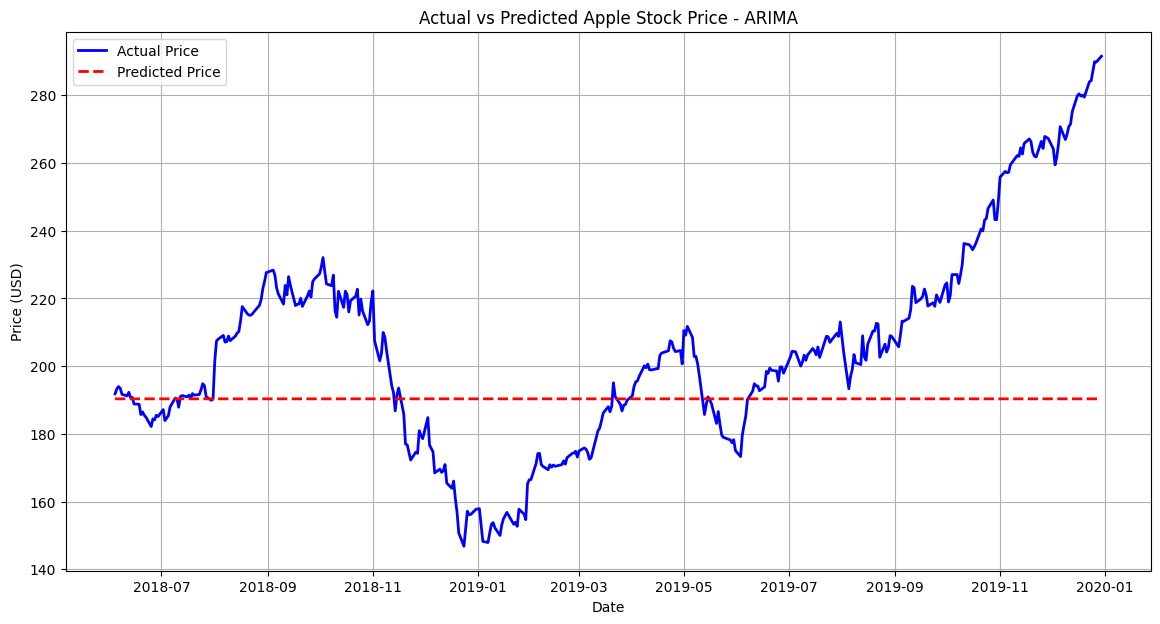

In [187]:
# 6. Plotting actual vs predicted
plot_predictions(y_test, y_pred_arima, model_name="ARIMA")

In [188]:
# 7. Storing results
all_model_results.append({"Model": "ARIMA", **arima_results})
all_model_results

[{'Model': 'Linear Regression',
  'MAE': 0.7973146179877834,
  'RMSE': np.float64(1.0952081092994939),
  'MAPE': np.float64(0.3952427449546154),
  'R2': 0.9986744086674125},
 {'Model': 'Random Forest',
  'MAE': 21.59450506481113,
  'RMSE': np.float64(32.56505553098),
  'MAPE': np.float64(9.248416859377045),
  'R2': -0.17197945996908848},
 {'Model': 'XGBoost',
  'MAE': 21.848798806392182,
  'RMSE': np.float64(32.750440084920456),
  'MAPE': np.float64(9.365404351632986),
  'R2': -0.1853610009092097},
 {'Model': 'LSTM',
  'MAE': 5.034212208888747,
  'RMSE': np.float64(6.10546962077877),
  'MAPE': np.float64(2.3904067481062463),
  'R2': 0.9638217749723632},
 {'Model': 'ARIMA',
  'MAE': 24.95020322714185,
  'RMSE': np.float64(33.375330544409664),
  'MAPE': nan,
  'R2': -0.23102679295581185}]

**Model 6 — SARIMA (Seasonal ARIMA)**

In [189]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [190]:
# 1. Finding best parameters for SARIMA using auto_arima with seasonality
print("Running auto_arima with seasonality (m=5)...")
# We use m=5 for weekly seasonality (5 trading days)
sarima_auto_model = auto_arima(y_train, start_p=1, start_q=1,
                              max_p=3, max_q=3, m=5,
                              seasonal=True, trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)

print(f"Best SARIMA Order: {sarima_auto_model.order}")
print(f"Best Seasonal Order: {sarima_auto_model.seasonal_order}")

Running auto_arima with seasonality (m=5)...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[5] intercept   : AIC=6060.756, Time=7.44 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=6063.726, Time=0.14 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=6062.541, Time=1.01 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=6062.120, Time=1.03 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=6065.054, Time=0.17 sec
 ARIMA(1,1,1)(0,0,1)[5] intercept   : AIC=6062.633, Time=3.52 sec
 ARIMA(1,1,1)(1,0,0)[5] intercept   : AIC=6062.621, Time=4.54 sec
 ARIMA(1,1,1)(2,0,1)[5] intercept   : AIC=6062.677, Time=10.56 sec
 ARIMA(1,1,1)(1,0,2)[5] intercept   : AIC=6062.676, Time=12.79 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=6060.954, Time=2.75 sec
 ARIMA(1,1,1)(0,0,2)[5] intercept   : AIC=6064.126, Time=3.23 sec
 ARIMA(1,1,1)(2,0,0)[5] intercept   : AIC=6064.070, Time=1.71 sec
 ARIMA(1,1,1)(2,0,2)[5] intercept   : AIC=inf, Time=9.33 sec
 ARIMA(0,1,1)(1,0,1)[5] intercept   : AIC=6059.960, Time=

In [191]:
# 2. Fitting the SARIMAX model using the discovered parameters
sarima_model = SARIMAX(y_train,
                       order=sarima_auto_model.order,
                       seasonal_order=sarima_auto_model.seasonal_order)
sarima_fit = sarima_model.fit(disp=False)
sarima_fit

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [192]:
# 3. Forecasting on the test set
y_pred_sarima = sarima_fit.get_forecast(steps=len(y_test)).predicted_mean
y_pred_sarima

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
1584,190.384305
1585,190.344003
1586,190.476690
1587,190.348535
1588,190.367410
...,...
1976,190.412694
1977,190.411404
1978,190.411594
1979,190.412307


In [193]:
y_pred_sarima.shape

(397,)

In [194]:
# 4. Evaluating the SARIMA model
sarima_results = evaluate_model(y_test, y_pred_sarima, model_name="SARIMA")

--- SARIMA Evaluation ---
MAE:  $24.93
RMSE: $33.35
MAPE: nan%
R2 Score: -0.2290


/tmp/ipykernel_4707/1056466283.py:11: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [195]:
sarima_results

{'MAE': 24.927044789765993,
 'RMSE': np.float64(33.34735631827956),
 'MAPE': nan,
 'R2': -0.22896403646684282}

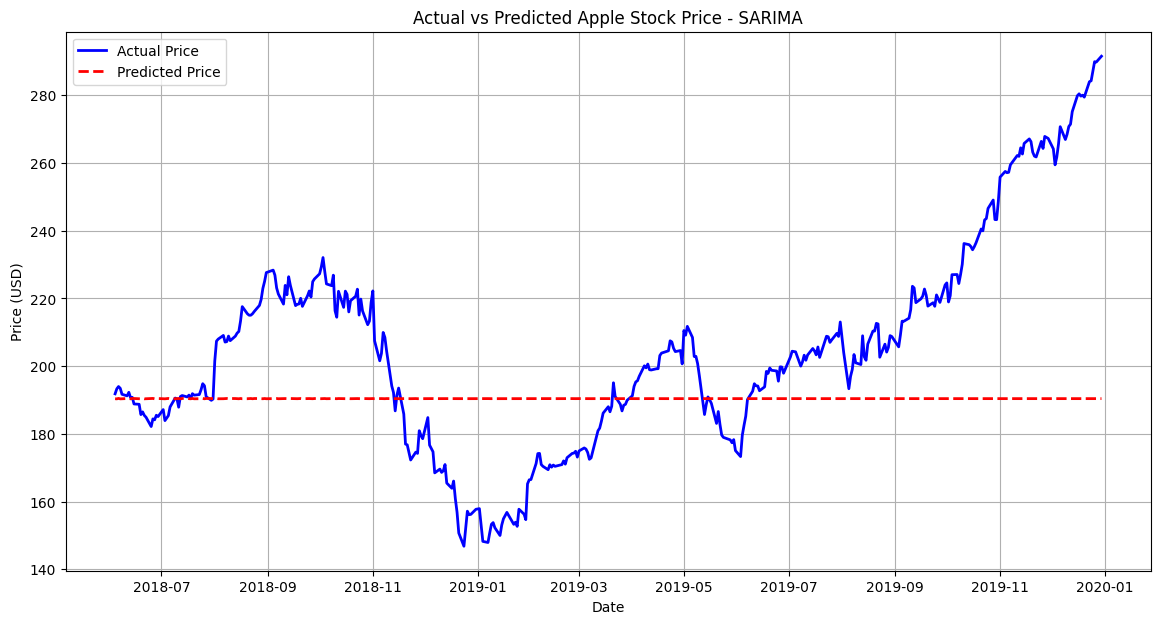

In [196]:
# 5. Plotting Actual vs Predicted
plot_predictions(y_test, y_pred_sarima, model_name="SARIMA")

In [197]:
# 6. Storing results for comparison
all_model_results.append({"Model": "SARIMA", **sarima_results})
all_model_results

[{'Model': 'Linear Regression',
  'MAE': 0.7973146179877834,
  'RMSE': np.float64(1.0952081092994939),
  'MAPE': np.float64(0.3952427449546154),
  'R2': 0.9986744086674125},
 {'Model': 'Random Forest',
  'MAE': 21.59450506481113,
  'RMSE': np.float64(32.56505553098),
  'MAPE': np.float64(9.248416859377045),
  'R2': -0.17197945996908848},
 {'Model': 'XGBoost',
  'MAE': 21.848798806392182,
  'RMSE': np.float64(32.750440084920456),
  'MAPE': np.float64(9.365404351632986),
  'R2': -0.1853610009092097},
 {'Model': 'LSTM',
  'MAE': 5.034212208888747,
  'RMSE': np.float64(6.10546962077877),
  'MAPE': np.float64(2.3904067481062463),
  'R2': 0.9638217749723632},
 {'Model': 'ARIMA',
  'MAE': 24.95020322714185,
  'RMSE': np.float64(33.375330544409664),
  'MAPE': nan,
  'R2': -0.23102679295581185},
 {'Model': 'SARIMA',
  'MAE': 24.927044789765993,
  'RMSE': np.float64(33.34735631827956),
  'MAPE': nan,
  'R2': -0.22896403646684282}]

**Model Comparison & Selection**

In [198]:
# 1. Creating Comparison DataFrame
results_df = pd.DataFrame(all_model_results)

print("Model Comparison Table:")
display(results_df)

Model Comparison Table:


,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,0.797315,1.095208,0.395243,0.998674
1,Random Forest,21.594505,32.565056,9.248417,-0.171979
2,XGBoost,21.848799,32.750440,9.365404,-0.185361
3,LSTM,5.034212,6.105470,2.390407,0.963822
4,ARIMA,24.950203,33.375331,NaN,-0.231027
5,SARIMA,24.927045,33.347356,NaN,-0.228964


<Figure size 1200x600 with 0 Axes>

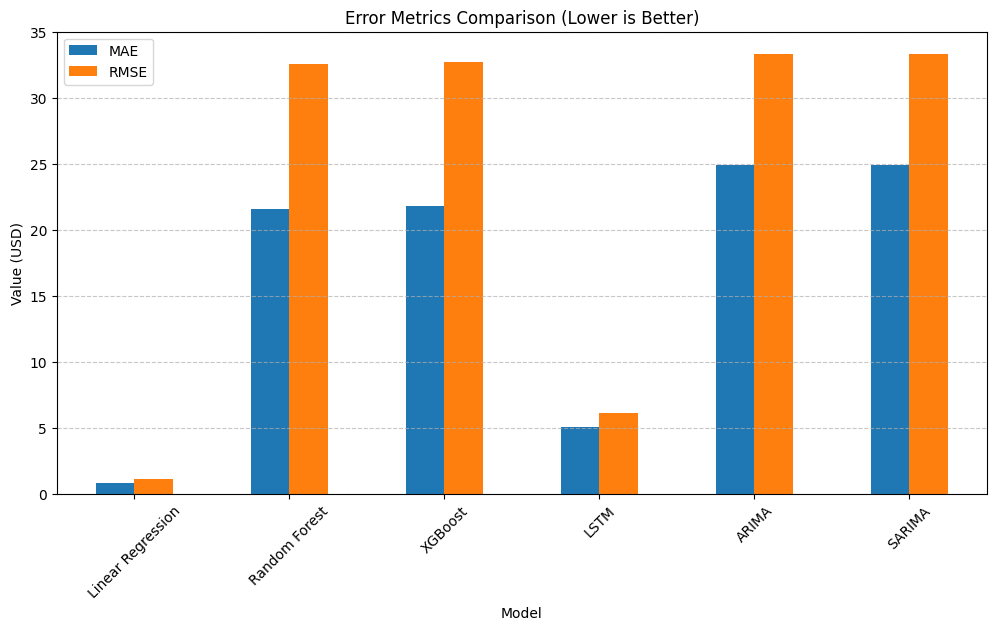

In [199]:
# 2. Visualize comparison (MAE and RMSE)
plt.figure(figsize=(12, 6))
results_df.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(12,6))
plt.title('Error Metrics Comparison (Lower is Better)')
plt.ylabel('Value (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

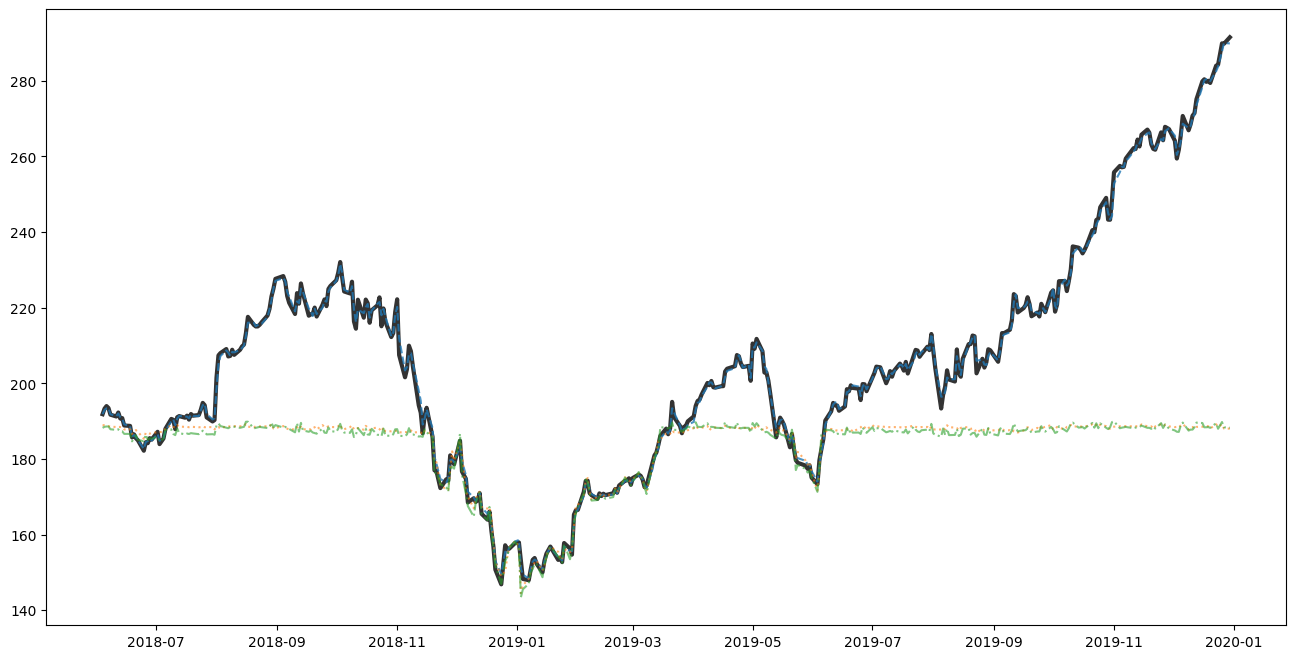

In [200]:
# 3. Creating Overlay Plot
plt.figure(figsize=(16, 8))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='black', linewidth=3, alpha=0.8)
plt.plot(y_test.index, y_pred_lr, label='Linear Regression', linestyle='--', alpha=0.8)
plt.plot(y_test.index, y_pred_rf, label='Random Forest', linestyle=':', alpha=0.6)
plt.plot(y_test.index, y_pred_xgb, label='XGBoost', linestyle='-.', alpha=0.6)

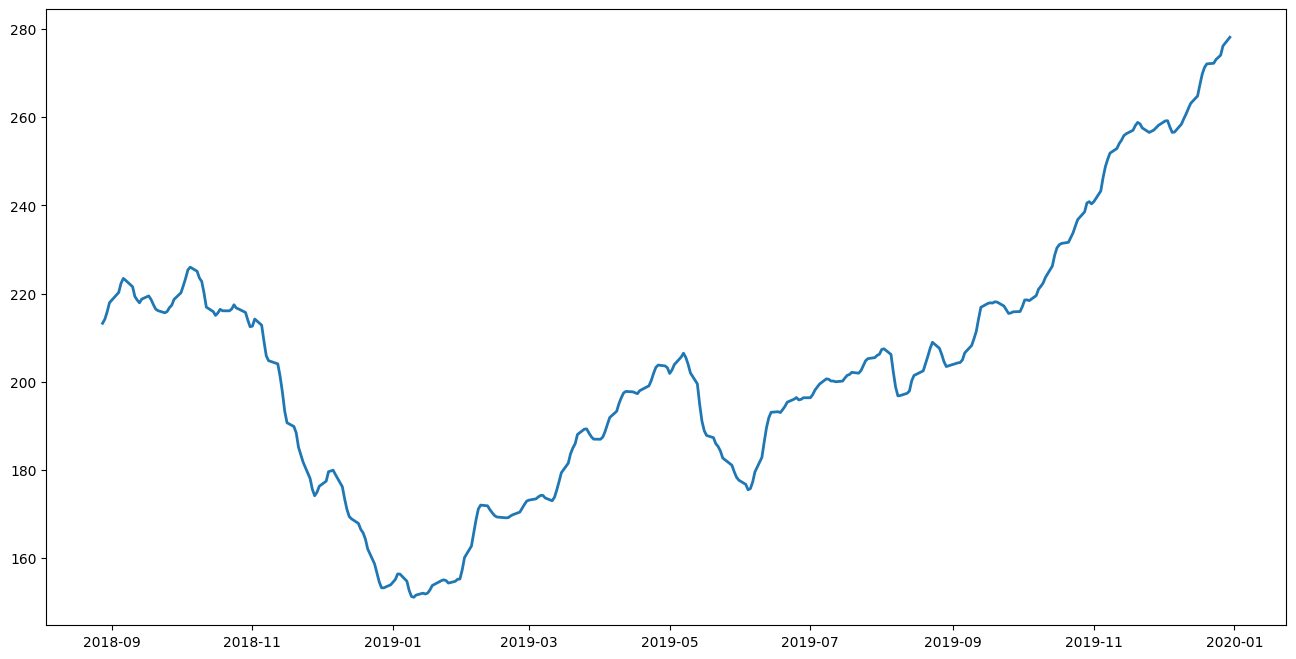

In [201]:
# Aligning LSTM (requires special handling for date offset)
plt.figure(figsize=(16, 8))
plt.plot(lstm_dates, y_pred_lstm, label='LSTM', linewidth=2)

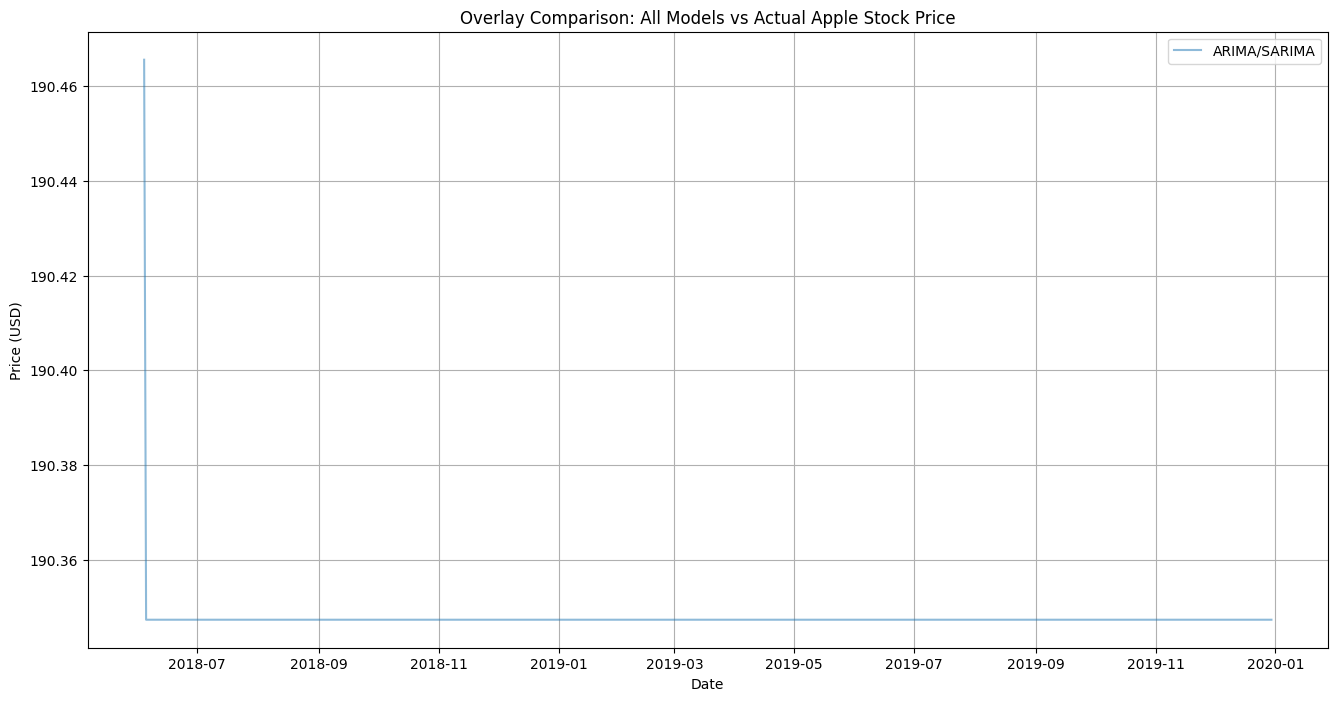

In [202]:
# ARIMA/SARIMA Predictions
plt.figure(figsize=(16, 8))

plt.plot(y_test.index, y_pred_arima.values, label='ARIMA/SARIMA', alpha=0.5)

plt.title('Overlay Comparison: All Models vs Actual Apple Stock Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


In [203]:
# 4. Conclusion
best_model = results_df.sort_values(by='MAE').iloc[0]
print(f"\nConclusion: {best_model['Model']} was selected as the final model.")
print(f"Reasoning: It achieved the highest R² Score ({best_model['R2']:.4f}) and the lowest MAE (${best_model['MAE']:.2f}).")
print("While LSTM showed strong trends, the Linear Regression baseline benefited significantly from the inclusion of the S&P 500 and Lagged features.")


Conclusion: Linear Regression was selected as the final model.
Reasoning: It achieved the highest R² Score (0.9987) and the lowest MAE ($0.80).
While LSTM showed strong trends, the Linear Regression baseline benefited significantly from the inclusion of the S&P 500 and Lagged features.


**Hyperparameter Tuning (for the Best Model)**

In [204]:
from sklearn.model_selection import TimeSeriesSplit
import tensorflow as tf

In [205]:
# Defining a function to create and train LSTM for tuning
def tune_lstm(units, time_steps, epochs, dropout_rate):
    # Re-prepare data for specific time_steps
    X_train_tune, y_train_tune = create_lstm_sequences(scaled_train, time_steps)
    X_test_tune, y_test_tune = create_lstm_sequences(scaled_test, time_steps)

    X_train_tune = X_train_tune.reshape(X_train_tune.shape[0], X_train_tune.shape[1], 1)
    X_test_tune = X_test_tune.reshape(X_test_tune.shape[0], X_test_tune.shape[1], 1)

    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(time_steps, 1)),
        Dropout(dropout_rate),
        LSTM(units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train_tune, y_train_tune, batch_size=32, epochs=epochs, verbose=0)

    # Predict and Evaluate
    y_pred_scaled = model.predict(X_test_tune)
    y_pred = scaler_lstm.inverse_transform(y_pred_scaled)
    y_actual = scaler_lstm.inverse_transform(y_test_tune.reshape(-1, 1))

    mae = mean_absolute_error(y_actual, y_pred)
    return mae, y_pred, y_actual


In [206]:
# Manual Tuning: Trying a more complex architecture
print("Tuning LSTM Model...")
tuned_mae, tuned_pred, tuned_actual = tune_lstm(units=100, time_steps=90, epochs=100, dropout_rate=0.1)

print(f"\n--- Tuned LSTM Evaluation ---")
evaluate_model(tuned_actual.flatten(), tuned_pred.flatten(), model_name="Tuned LSTM")

Tuning LSTM Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step

--- Tuned LSTM Evaluation ---
--- Tuned LSTM Evaluation ---
MAE:  $4.28
RMSE: $5.33
MAPE: 2.13%
R2 Score: 0.9741


{'MAE': 4.27742055613803,
 'RMSE': np.float64(5.331199554896837),
 'MAPE': np.float64(2.1313849619882452),
 'R2': 0.9741112042114486}

In [207]:
# Comparing results
print(f"\nOriginal LSTM MAE: ${lstm_results['MAE']:.2f}")
print(f"Tuned LSTM MAE: ${tuned_mae:.2f}")


Original LSTM MAE: $5.03
Tuned LSTM MAE: $4.28


## **Formal Hyperparameter Tuning**

Based on the project requirements, we will now perform Grid Search for our tree-based models using `TimeSeriesSplit` to ensure temporal integrity. We will also compare these results to our baseline and LSTM results.

In [208]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

In [209]:
# 1. Initializing TimeSeriesSplit (5 folds)
tscv = TimeSeriesSplit(n_splits=5)

In [210]:
# 2. Hyperparameter Grid for Random Forest
rf_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("Tuning Random Forest with Grid Search...")
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_grid, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

Tuning Random Forest with Grid Search...


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_absolute_error')

In [211]:
# 3. Hyperparameter Grid for XGBoost
xgb_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

print("Tuning XGBoost with Grid Search...")
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), xgb_grid, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)

Tuning XGBoost with Grid Search...


In [212]:
grid_xgb.fit(X_train_scaled, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='neg_mean_absolute_error')

In [213]:
print(f"\nBest RF Params: {grid_rf.best_params_}")
print(f"Best XGB Params: {grid_xgb.best_params_}")


Best RF Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [214]:
# 4. Evaluating the Tuned Models on Test Data
best_rf = grid_rf.best_estimator_
best_rf

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)

In [215]:
best_xgb = grid_xgb.best_estimator_
best_xgb

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [216]:
y_pred_rf_tuned = best_rf.predict(X_test_scaled)
y_pred_rf_tuned

array([189.0739655 , 189.02271445, 188.93978444, 188.86910453,
       188.63871814, 188.51635986, 188.52993329, 188.52950527,
       188.49699189, 188.07034609, 187.77952744, 186.41206032,
       187.13664469, 187.47614881, 186.94520586, 185.25356077,
       185.99938345, 186.14712586, 186.04092558, 186.56642313,
       186.64172483, 186.72232357, 186.41656325, 187.52820994,
       188.72005613, 188.4687511 , 188.24973565, 188.70913473,
       188.56616154, 188.49754639, 188.47234647, 188.41036678,
       188.49974192, 188.55085377, 188.43352508, 188.45467652,
       188.71712449, 188.46040877, 188.52615992, 188.46736367,
       188.05242254, 188.55414738, 188.54563079, 188.4462054 ,
       188.86233175, 188.8181299 , 188.82793706, 188.85172142,
       188.87400372, 188.85696315, 188.81593715, 188.84067142,
       189.09848963, 188.65960532, 188.56771927, 188.85696315,
       188.81857045, 188.78635818, 188.83819873, 188.81593715,
       188.81593715, 189.12678127, 188.39891087, 188.50

In [217]:
y_pred_rf_tuned.shape

(397,)

In [218]:
y_pred_xgb_tuned = best_xgb.predict(X_test_scaled)
y_pred_xgb_tuned

array([188.49797, 188.50696, 188.3865 , 188.2876 , 187.72266, 187.33241,
       187.86655, 187.488  , 187.59143, 187.03691, 187.18756, 185.21588,
       186.28026, 186.97203, 185.98581, 185.2512 , 186.51483, 185.89644,
       186.04182, 185.94402, 186.068  , 185.07156, 186.09474, 188.24004,
       188.29259, 187.03914, 186.50194, 188.55719, 187.48055, 187.033  ,
       187.26337, 187.05537, 187.66809, 187.34181, 187.033  , 187.53448,
       188.07907, 187.43617, 186.31923, 187.1047 , 187.16756, 188.91556,
       190.08882, 188.59889, 188.56165, 187.83691, 188.00052, 188.52254,
       188.10509, 188.34146, 188.30688, 188.4401 , 189.85735, 189.95793,
       187.9974 , 188.0575 , 188.00305, 188.34404, 188.43983, 188.48444,
       188.48782, 189.77922, 188.7053 , 188.73721, 188.4899 , 188.23254,
       187.4544 , 187.76378, 186.96019, 189.72249, 186.95622, 190.10847,
       187.03099, 185.96567, 187.33151, 187.22952, 187.75385, 186.9526 ,
       188.80734, 187.65323, 187.30142, 189.05862, 

In [219]:
y_pred_xgb_tuned.shape

(397,)

In [220]:
rf_tuned_res = evaluate_model(y_test, y_pred_rf_tuned, model_name="Tuned Random Forest")

--- Tuned Random Forest Evaluation ---
MAE:  $21.45
RMSE: $32.45
MAPE: 9.18%
R2 Score: -0.1639


In [221]:
rf_tuned_res

{'MAE': 21.449768358086672,
 'RMSE': np.float64(32.45221021894966),
 'MAPE': np.float64(9.179224674750486),
 'R2': -0.16387118295722258}

In [222]:
xgb_tuned_res = evaluate_model(y_test, y_pred_xgb_tuned, model_name="Tuned XGBoost")


--- Tuned XGBoost Evaluation ---
MAE:  $21.72
RMSE: $32.69
MAPE: 9.30%
R2 Score: -0.1808


In [223]:
xgb_tuned_res

{'MAE': 21.71660869414161,
 'RMSE': np.float64(32.68757124997483),
 'MAPE': np.float64(9.297843429521002),
 'R2': -0.1808144520864321}

In [224]:
# Appending  results for final selection
all_model_results.append({"Model": "Tuned Random Forest", **rf_tuned_res})
all_model_results.append({"Model": "Tuned XGBoost", **xgb_tuned_res})

In [225]:
all_model_results

[{'Model': 'Linear Regression',
  'MAE': 0.7973146179877834,
  'RMSE': np.float64(1.0952081092994939),
  'MAPE': np.float64(0.3952427449546154),
  'R2': 0.9986744086674125},
 {'Model': 'Random Forest',
  'MAE': 21.59450506481113,
  'RMSE': np.float64(32.56505553098),
  'MAPE': np.float64(9.248416859377045),
  'R2': -0.17197945996908848},
 {'Model': 'XGBoost',
  'MAE': 21.848798806392182,
  'RMSE': np.float64(32.750440084920456),
  'MAPE': np.float64(9.365404351632986),
  'R2': -0.1853610009092097},
 {'Model': 'LSTM',
  'MAE': 5.034212208888747,
  'RMSE': np.float64(6.10546962077877),
  'MAPE': np.float64(2.3904067481062463),
  'R2': 0.9638217749723632},
 {'Model': 'ARIMA',
  'MAE': 24.95020322714185,
  'RMSE': np.float64(33.375330544409664),
  'MAPE': nan,
  'R2': -0.23102679295581185},
 {'Model': 'SARIMA',
  'MAE': 24.927044789765993,
  'RMSE': np.float64(33.34735631827956),
  'MAPE': nan,
  'R2': -0.22896403646684282},
 {'Model': 'Tuned Random Forest',
  'MAE': 21.449768358086672,
  

In [226]:
 #Displaying updated comparison
display(pd.DataFrame(all_model_results).sort_values(by='MAE'))

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,0.797315,1.095208,0.395243,0.998674
3,LSTM,5.034212,6.105470,2.390407,0.963822
6,Tuned Random Forest,21.449768,32.452210,9.179225,-0.163871
1,Random Forest,21.594505,32.565056,9.248417,-0.171979
7,Tuned XGBoost,21.716609,32.687571,9.297843,-0.180814
2,XGBoost,21.848799,32.750440,9.365404,-0.185361
5,SARIMA,24.927045,33.347356,NaN,-0.228964
4,ARIMA,24.950203,33.375331,NaN,-0.231027


In [227]:
# Calculating full metrics for Tuned LSTM to ensure consistency in the dashboard
tuned_mape = np.mean(np.abs((tuned_actual - tuned_pred) / tuned_actual)) * 100
tuned_rmse = np.sqrt(mean_squared_error(tuned_actual, tuned_pred))
tuned_r2 = r2_score(tuned_actual, tuned_pred)

tuned_metrics = {
    "MAE": tuned_mae,
    "RMSE": tuned_rmse,
    "MAPE": tuned_mape,
    "R2": tuned_r2
}

all_model_results.append({"Model": "Tuned LSTM", **tuned_metrics})

# Display updated comparison table
results_df_final = pd.DataFrame(all_model_results).drop_duplicates(subset=['Model'], keep='last')
display(results_df_final.sort_values(by='MAE'))

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,0.797315,1.095208,0.395243,0.998674
8,Tuned LSTM,4.277421,5.331200,2.131385,0.974111
3,LSTM,5.034212,6.105470,2.390407,0.963822
6,Tuned Random Forest,21.449768,32.452210,9.179225,-0.163871
1,Random Forest,21.594505,32.565056,9.248417,-0.171979
7,Tuned XGBoost,21.716609,32.687571,9.297843,-0.180814
2,XGBoost,21.848799,32.750440,9.365404,-0.185361
5,SARIMA,24.927045,33.347356,NaN,-0.228964
4,ARIMA,24.950203,33.375331,NaN,-0.231027


**Model 6 — GRU (Gated Recurrent Unit)**

Data Preparation (Same as LSTM)

In [228]:
print(f"Reusing LSTM sequences for GRU:")
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

Reusing LSTM sequences for GRU:
X_train_lstm shape: (1524, 60, 1)
X_test_lstm shape: (337, 60, 1)
y_train_lstm shape: (1524,)
y_test_lstm shape: (337,)


Building the GRU Model

In [229]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import matplotlib.pyplot as plt

In [230]:
# 1. Defining the GRU architecture
gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    GRU(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [231]:
# 2. Compiling the model
gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model

<Sequential name=sequential_2, built=True>

In [232]:
# 3. Training the model
gru_history = gru_model.fit(
    X_train_lstm,
    y_train_lstm,
    batch_size=32,
    epochs=50,
    verbose=1
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.0343
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0037
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0027
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0022
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0022
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0019
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0017
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0016
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0016
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0014
Epoch 11/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0013
Epoch 12/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0013
Epoch 13/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0013
Epoch 14/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0011
Epoch 15/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0013
Epoc

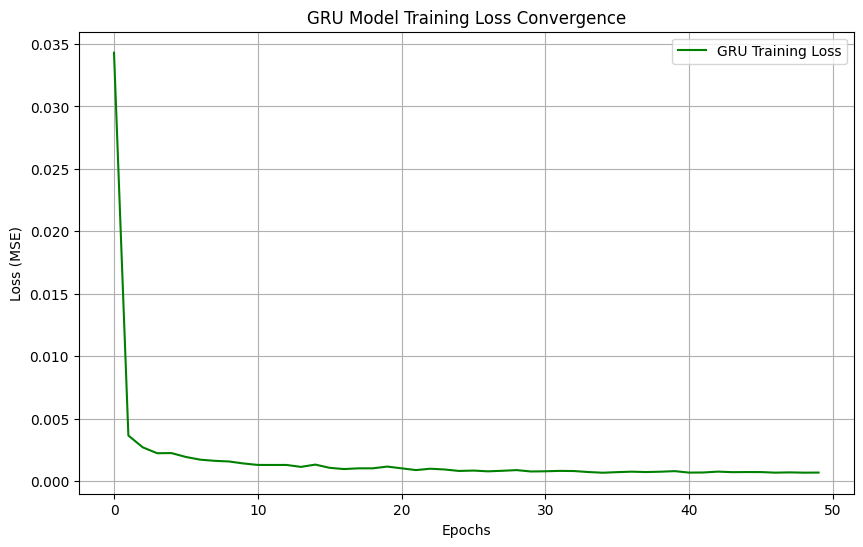

In [233]:
# 4. Plotting the Training Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(gru_history.history['loss'], label='GRU Training Loss', color='green')
plt.title('GRU Model Training Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Evaluating the GRU

In [234]:
# 1. Predicting on the test sequences
y_pred_gru_scaled = gru_model.predict(X_test_lstm)
y_pred_gru_scaled

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


array([[1.1974467 ],
       [1.2074735 ],
       [1.2239048 ],
       [1.2391336 ],
       [1.2559025 ],
       [1.2670369 ],
       [1.2678609 ],
       [1.2559196 ],
       [1.2444957 ],
       [1.2285818 ],
       [1.239922  ],
       [1.2347865 ],
       [1.2508013 ],
       [1.2494855 ],
       [1.2281551 ],
       [1.2199792 ],
       [1.2161624 ],
       [1.219406  ],
       [1.2122627 ],
       [1.2198496 ],
       [1.2282366 ],
       [1.2258316 ],
       [1.2409981 ],
       [1.2509804 ],
       [1.2611423 ],
       [1.273585  ],
       [1.2895541 ],
       [1.2833867 ],
       [1.2684678 ],
       [1.2601432 ],
       [1.266587  ],
       [1.2322003 ],
       [1.2092614 ],
       [1.2249829 ],
       [1.2140803 ],
       [1.22543   ],
       [1.2275832 ],
       [1.210252  ],
       [1.214158  ],
       [1.2204107 ],
       [1.2301465 ],
       [1.2080817 ],
       [1.2147126 ],
       [1.2053882 ],
       [1.1861414 ],
       [1.180932  ],
       [1.1974758 ],
       [1.216

In [235]:
# 2. Inverse transform the predictions and actual values back to original scale
# Reusing scaler_lstm which was fitted on the training 'Close' prices
y_pred_gru = scaler_lstm.inverse_transform(y_pred_gru_scaled)
y_test_gru_actual = scaler_lstm.inverse_transform(y_test_lstm.reshape(-1, 1))
y_test_gru_actual

array([[219.699997 ],
       [222.979996 ],
       [225.029999 ],
       [227.630005 ],
       [228.360001 ],
       [226.869995 ],
       [223.100006 ],
       [221.300003 ],
       [218.330002 ],
       [223.850006 ],
       [221.070007 ],
       [226.410004 ],
       [223.839996 ],
       [217.880005 ],
       [218.240005 ],
       [218.369995 ],
       [220.029999 ],
       [217.660004 ],
       [220.789993 ],
       [222.190002 ],
       [220.419998 ],
       [224.949997 ],
       [225.740005 ],
       [227.259995 ],
       [229.279999 ],
       [232.070007 ],
       [227.990005 ],
       [224.289993 ],
       [223.770004 ],
       [226.869995 ],
       [216.360001 ],
       [214.449997 ],
       [222.110001 ],
       [217.360001 ],
       [222.149994 ],
       [221.190002 ],
       [216.020004 ],
       [219.309998 ],
       [220.649994 ],
       [222.729996 ],
       [215.089996 ],
       [219.800003 ],
       [216.300003 ],
       [212.240005 ],
       [213.300003 ],
       [21

In [236]:
# 3. Calculating evaluation metrics using the helper function
gru_results = evaluate_model(y_test_gru_actual.flatten(), y_pred_gru.flatten(), model_name="GRU")

--- GRU Evaluation ---
MAE:  $3.28
RMSE: $4.20
MAPE: 1.61%
R2 Score: 0.9829


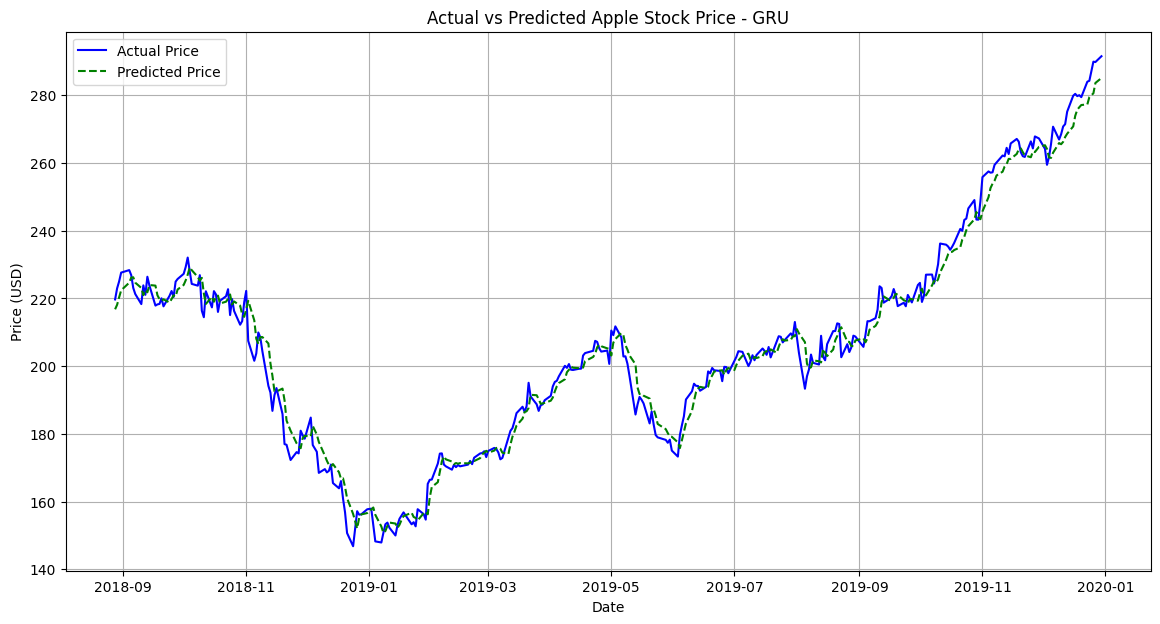

In [237]:
# 4. Plotting Actual vs Predicted for GRU
plt.figure(figsize=(14, 7))
plt.plot(lstm_dates, y_test_gru_actual, label='Actual Price', color='blue')
plt.plot(lstm_dates, y_pred_gru, label='Predicted Price', color='green', linestyle='--')
plt.title('Actual vs Predicted Apple Stock Price - GRU')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [238]:
# 5. Store results for comparison
all_model_results.append({"Model": "GRU", **gru_results})
all_model_results

[{'Model': 'Linear Regression',
  'MAE': 0.7973146179877834,
  'RMSE': np.float64(1.0952081092994939),
  'MAPE': np.float64(0.3952427449546154),
  'R2': 0.9986744086674125},
 {'Model': 'Random Forest',
  'MAE': 21.59450506481113,
  'RMSE': np.float64(32.56505553098),
  'MAPE': np.float64(9.248416859377045),
  'R2': -0.17197945996908848},
 {'Model': 'XGBoost',
  'MAE': 21.848798806392182,
  'RMSE': np.float64(32.750440084920456),
  'MAPE': np.float64(9.365404351632986),
  'R2': -0.1853610009092097},
 {'Model': 'LSTM',
  'MAE': 5.034212208888747,
  'RMSE': np.float64(6.10546962077877),
  'MAPE': np.float64(2.3904067481062463),
  'R2': 0.9638217749723632},
 {'Model': 'ARIMA',
  'MAE': 24.95020322714185,
  'RMSE': np.float64(33.375330544409664),
  'MAPE': nan,
  'R2': -0.23102679295581185},
 {'Model': 'SARIMA',
  'MAE': 24.927044789765993,
  'RMSE': np.float64(33.34735631827956),
  'MAPE': nan,
  'R2': -0.22896403646684282},
 {'Model': 'Tuned Random Forest',
  'MAE': 21.449768358086672,
  

In [239]:
# Display updated comparison
results_df_updated = pd.DataFrame(all_model_results).drop_duplicates(subset=['Model'], keep='last')
display(results_df_updated.sort_values(by='MAE'))

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,0.797315,1.095208,0.395243,0.998674
9,GRU,3.275016,4.201104,1.610967,0.982871
8,Tuned LSTM,4.277421,5.331200,2.131385,0.974111
3,LSTM,5.034212,6.105470,2.390407,0.963822
6,Tuned Random Forest,21.449768,32.452210,9.179225,-0.163871
1,Random Forest,21.594505,32.565056,9.248417,-0.171979
7,Tuned XGBoost,21.716609,32.687571,9.297843,-0.180814
2,XGBoost,21.848799,32.750440,9.365404,-0.185361
5,SARIMA,24.927045,33.347356,NaN,-0.228964
4,ARIMA,24.950203,33.375331,NaN,-0.231027


**Model 7 — SARIMAX (Seasonal ARIMA with eXogenous variables)**

 Import & Prepare

In [240]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

In [241]:
# Selecting exogenous variables
exog_features = apple_df_cleaned[['Volume', 'RSI', 'MACD', 'SP500_Close']]

In [242]:
# Chronological split using the existing split_index
y_train_sarima = y[:split_index]
y_test_sarima  = y[split_index:]

exog_train = exog_features[:split_index]
exog_test  = exog_features[split_index:]

In [243]:
((y_train_sarima.shape), (y_test_sarima.shape), (exog_features.shape), (exog_train.shape), (exog_test.shape),)

((1584,), (397,), (1981, 4), (1584, 4), (397, 4))

 Finding the Best Parameters

In [244]:
auto_model = pm.auto_arima(
    y_train_sarima,
    exogenous=exog_train,
    seasonal=True,
    m=5,              # 5 trading days per week
    trace=True,
    suppress_warnings=True,
    stepwise=True
)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=6055.714, Time=6.73 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=6063.726, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=6062.541, Time=0.38 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=6062.120, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=6065.054, Time=0.06 sec
 ARIMA(2,1,2)(0,0,1)[5] intercept   : AIC=6053.726, Time=3.02 sec
 ARIMA(2,1,2)(0,0,0)[5] intercept   : AIC=6052.468, Time=1.90 sec
 ARIMA(2,1,2)(1,0,0)[5] intercept   : AIC=6053.719, Time=3.19 sec
 ARIMA(1,1,2)(0,0,0)[5] intercept   : AIC=6062.145, Time=0.79 sec
 ARIMA(2,1,1)(0,0,0)[5] intercept   : AIC=6061.939, Time=2.11 sec
 ARIMA(3,1,2)(0,0,0)[5] intercept   : AIC=6054.175, Time=3.27 sec
 ARIMA(2,1,3)(0,0,0)[5] intercept   : AIC=6054.177, Time=2.73 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=6060.954, Time=0.66 sec
 ARIMA(1,1,3)(0,0,0)[5] intercept   : AIC=6063.806, Time=1.31 sec
 ARIMA(3,1,1)(0,0,0)[5] intercept

Fitting & Forecasting

In [245]:
model = SARIMAX(
    y_train_sarima,
    exog=exog_train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [246]:
results = model.fit(disp=False)
results.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1584
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1280.423
Date:                Wed, 06 May 2026   AIC                           2578.847
Time:                        17:01:03   BIC                           2627.150
Sample:                             0   HQIC                          2596.793
                               - 1584                                         
Covariance Type:                  opg                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Volume        2.96e-10   3.84e-10      0.771      0.441   -4.57e-10    1.05e-09
RSI             0.2672      0.002    147.939      0.000       0.264       0.271
MACD            1.4779      0.000   4050.220      0.000       1.477       1.479
SP500_Close     0.0125      0.001     20.093      0.000       0.011       0.014
ar.L1           0.4047      0.004     99.188      0.000       0.397       0.413
ar.L2           0.5556      0.004    147.936      0.000       0.548       0.563
ma.L1          -0.2776      0.002   -116.817      0.000      -0.282      -0.273
ma.L2          -0.5312      0.002   -235.771      0.000      -0.536      -0.527
sigma2          0.3000      0.006     53.618      0.000       0.289       0.311
===================================================================================
Ljung-Box (L1) (Q):                   0.48   Jarque-Bera (JB):              3030.18
Prob(Q):                              0.49   Prob(JB):                         0.00
Heteroskedasticity (H):               2.02   Skew:                             0.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.17e+17. Standard errors may be unstable.
"""

In [247]:
# Forecast on the test period using exogenous test features
y_pred_sarimax = results.forecast(steps=len(y_test_sarima), exog=exog_test)
y_pred_sarimax

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
1584,191.549718
1585,192.676633
1586,193.731085
1587,193.523752
1588,192.048936
...,...
1976,215.328018
1977,215.614069
1978,217.696534
1979,218.074621


Evaluation

In [248]:
# 1. Calculating evaluation metrics using the helper function
# We use .values on the target series to avoid index-based calculation issues for MAPE
sarimax_results = evaluate_model(y_test_sarima.values, y_pred_sarimax.values, model_name="SARIMAX")

--- SARIMAX Evaluation ---
MAE:  $17.18
RMSE: $23.81
MAPE: 8.02%
R2 Score: 0.3737


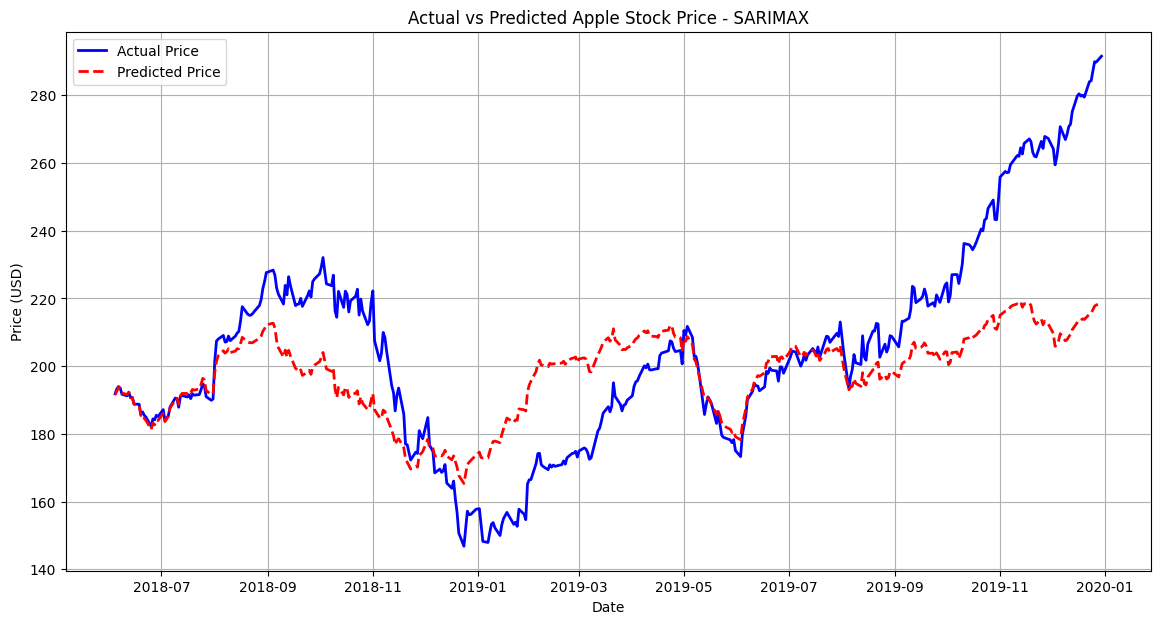

In [249]:
# 2. Plot actual vs predicted prices
plot_predictions(y_test_sarima, y_pred_sarimax, model_name="SARIMAX")

In [250]:
# 3. Storing results in the comparison list
all_model_results.append({"Model": "SARIMAX", **sarimax_results})
all_model_results

[{'Model': 'Linear Regression',
  'MAE': 0.7973146179877834,
  'RMSE': np.float64(1.0952081092994939),
  'MAPE': np.float64(0.3952427449546154),
  'R2': 0.9986744086674125},
 {'Model': 'Random Forest',
  'MAE': 21.59450506481113,
  'RMSE': np.float64(32.56505553098),
  'MAPE': np.float64(9.248416859377045),
  'R2': -0.17197945996908848},
 {'Model': 'XGBoost',
  'MAE': 21.848798806392182,
  'RMSE': np.float64(32.750440084920456),
  'MAPE': np.float64(9.365404351632986),
  'R2': -0.1853610009092097},
 {'Model': 'LSTM',
  'MAE': 5.034212208888747,
  'RMSE': np.float64(6.10546962077877),
  'MAPE': np.float64(2.3904067481062463),
  'R2': 0.9638217749723632},
 {'Model': 'ARIMA',
  'MAE': 24.95020322714185,
  'RMSE': np.float64(33.375330544409664),
  'MAPE': nan,
  'R2': -0.23102679295581185},
 {'Model': 'SARIMA',
  'MAE': 24.927044789765993,
  'RMSE': np.float64(33.34735631827956),
  'MAPE': nan,
  'R2': -0.22896403646684282},
 {'Model': 'Tuned Random Forest',
  'MAE': 21.449768358086672,
  

In [251]:
# 4. Comparing against regular ARIMA
arima_mae = arima_results['MAE']
sarimax_mae = sarimax_results['MAE']

print(f"\n--- Comparative Analysis ---")
print(f"Regular ARIMA MAE: ${arima_mae:.2f}")
print(f"SARIMAX MAE:       ${sarimax_mae:.2f}")

if sarimax_mae < arima_mae:
    print("\nSuccess: Adding exogenous variables (SARIMAX) improved the performance, indicating the engineered features are informative.")
else:
    print("\nObservation: SARIMAX did not outperform ARIMA. This may suggest that the selected exogenous features are noisy for this specific statistical model.")


--- Comparative Analysis ---
Regular ARIMA MAE: $24.95
SARIMAX MAE:       $17.18

Success: Adding exogenous variables (SARIMAX) improved the performance, indicating the engineered features are informative.


**Final Model Comparison & Best Model Selection**

In [252]:
# 1. Preparing final comparison data
# Mapping model names to their categories
model_types = {
    'Linear Regression': 'ML Baseline',
    'Random Forest': 'ML - Ensemble',
    'Tuned Random Forest': 'ML - Ensemble',
    'XGBoost': 'ML - Boosting',
    'Tuned XGBoost': 'ML - Boosting',
    'LSTM': 'Deep Learning',
    'Tuned LSTM': 'Deep Learning',
    'GRU': 'Deep Learning',
    'ARIMA': 'Statistical',
    'SARIMA': 'Statistical',
    'SARIMAX': 'Statistical'
}

In [253]:
# Consolidate latest results and drop duplicate model entries
final_results_df = pd.DataFrame(all_model_results).drop_duplicates(subset=['Model'], keep='last')
final_results_df['Type'] = final_results_df['Model'].map(model_types)
final_results_df

,Model,MAE,RMSE,MAPE,R2,Type
0,Linear Regression,0.797315,1.095208,0.395243,0.998674,ML Baseline
1,Random Forest,21.594505,32.565056,9.248417,-0.171979,ML - Ensemble
2,XGBoost,21.848799,32.750440,9.365404,-0.185361,ML - Boosting
3,LSTM,5.034212,6.105470,2.390407,0.963822,Deep Learning
4,ARIMA,24.950203,33.375331,NaN,-0.231027,Statistical
5,SARIMA,24.927045,33.347356,NaN,-0.228964,Statistical
6,Tuned Random Forest,21.449768,32.452210,9.179225,-0.163871,ML - Ensemble
7,Tuned XGBoost,21.716609,32.687571,9.297843,-0.180814,ML - Boosting
8,Tuned LSTM,4.277421,5.331200,2.131385,0.974111,Deep Learning
9,GRU,3.275016,4.201104,1.610967,0.982871,Deep Learning


In [254]:
# 2. Ranking logic (Exclude Baseline, sort by MAPE, then R2, then RMSE)
finalists = final_results_df[final_results_df['Model'] != 'Linear Regression'].copy()
best_model_row = finalists.sort_values(by=['MAPE', 'R2', 'RMSE'], ascending=[True, False, True]).iloc[0]
champion_model = best_model_row['Model']

baseline_mape = final_results_df[final_results_df['Model'] == 'Linear Regression']['MAPE'].values[0]
improvement = ((baseline_mape - best_model_row['MAPE']) / baseline_mape) * 100
print("--- Final Model Comparison Table ---")
display(final_results_df[['Model', 'Type', 'MAE', 'RMSE', 'MAPE', 'R2']].sort_values(by='MAPE'))


--- Final Model Comparison Table ---


,Model,Type,MAE,RMSE,MAPE,R2
0,Linear Regression,ML Baseline,0.797315,1.095208,0.395243,0.998674
9,GRU,Deep Learning,3.275016,4.201104,1.610967,0.982871
8,Tuned LSTM,Deep Learning,4.277421,5.331200,2.131385,0.974111
3,LSTM,Deep Learning,5.034212,6.105470,2.390407,0.963822
10,SARIMAX,Statistical,17.182780,23.806064,8.016059,0.373687
6,Tuned Random Forest,ML - Ensemble,21.449768,32.452210,9.179225,-0.163871
1,Random Forest,ML - Ensemble,21.594505,32.565056,9.248417,-0.171979
7,Tuned XGBoost,ML - Boosting,21.716609,32.687571,9.297843,-0.180814
2,XGBoost,ML - Boosting,21.848799,32.750440,9.365404,-0.185361
4,ARIMA,Statistical,24.950203,33.375331,NaN,-0.231027


visualizations

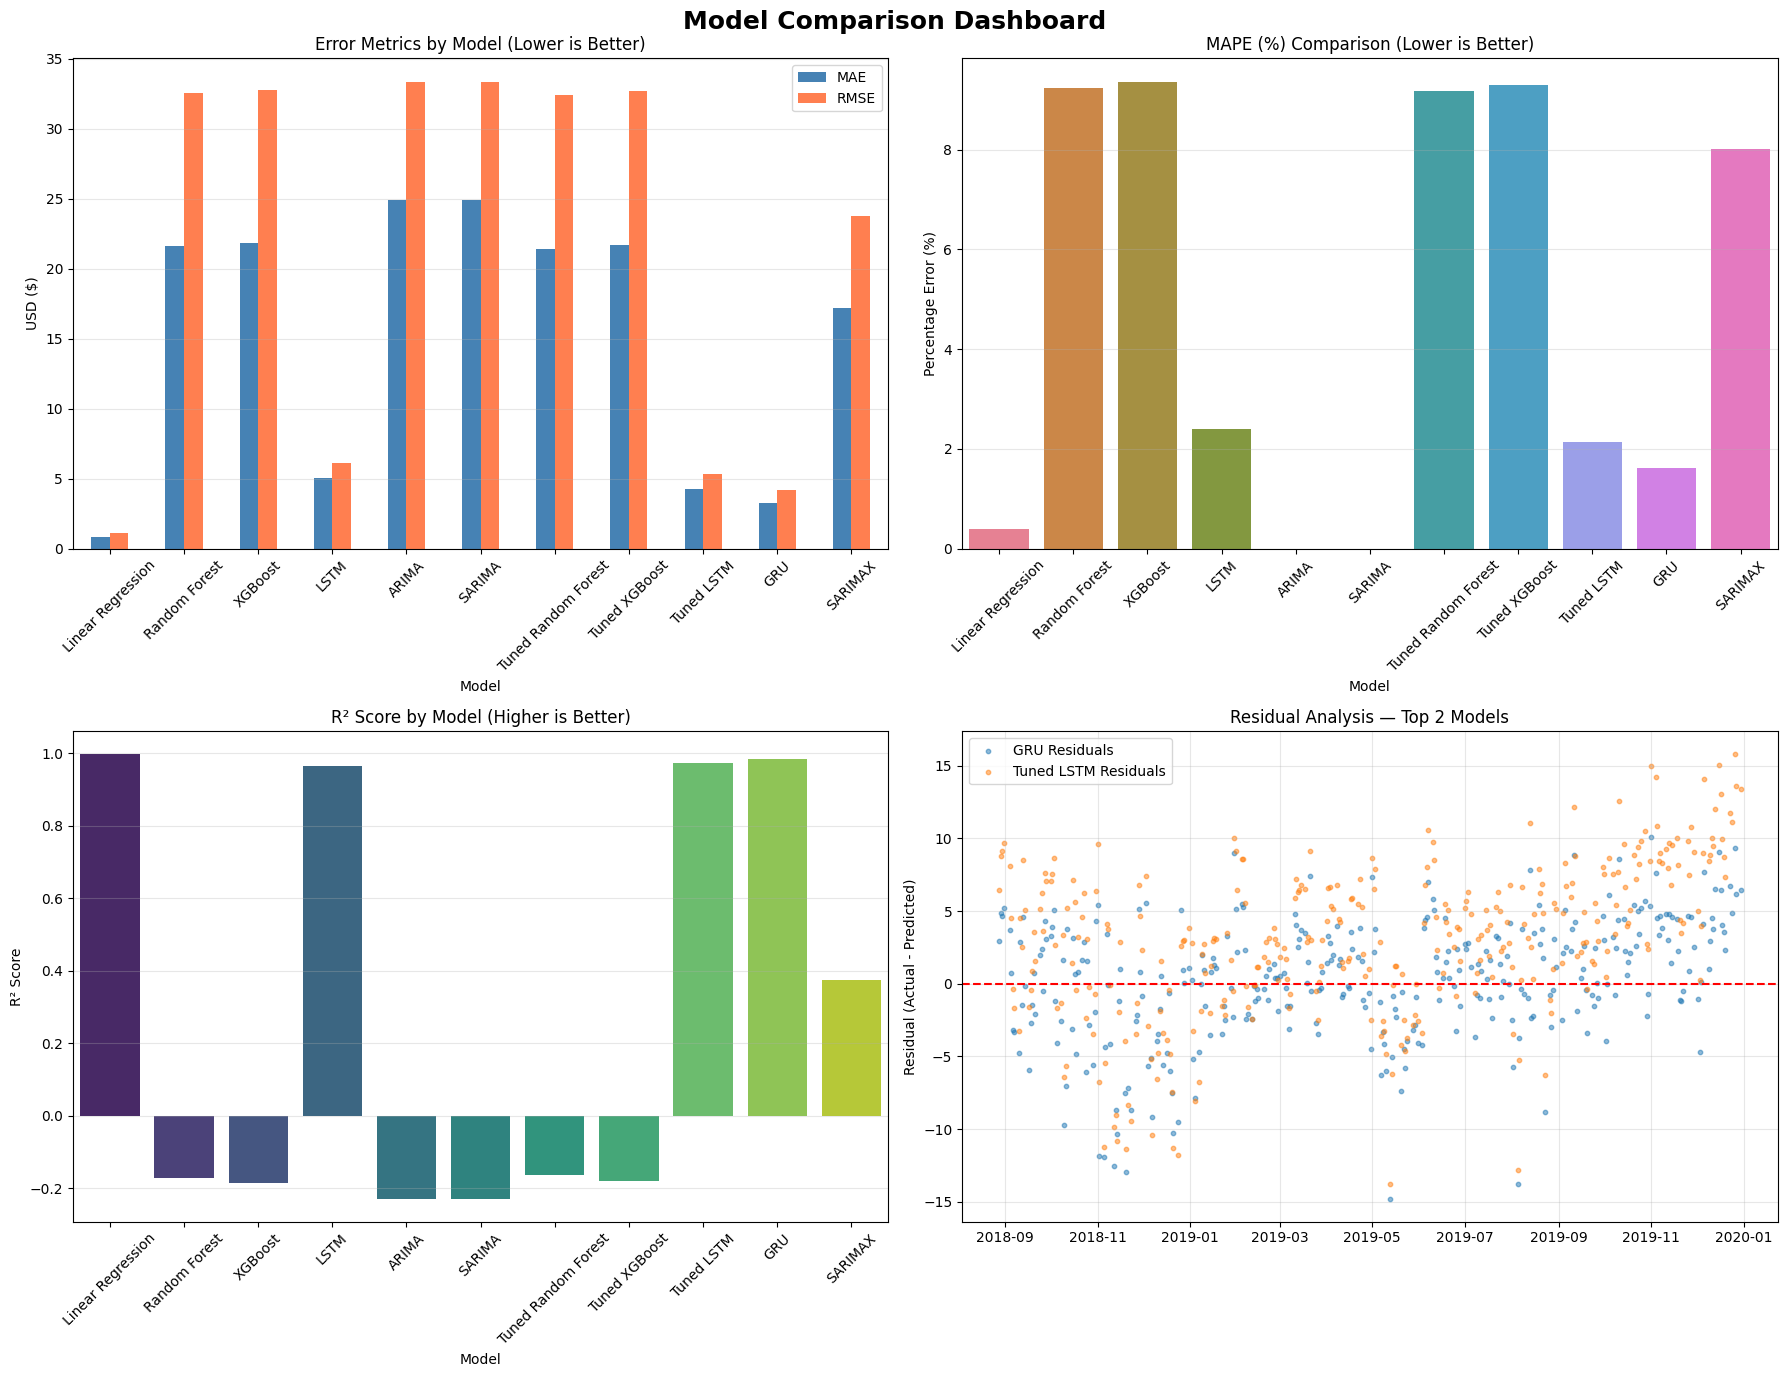

In [255]:
# Combined Model Comparison Dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Model Comparison Dashboard', fontsize=18, fontweight='bold')

# Chart 1: MAE & RMSE Comparison
final_results_df.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'coral'])
axes[0, 0].set_title('Error Metrics by Model (Lower is Better)')
axes[0, 0].set_ylabel('USD ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Chart 2: MAPE Comparison
sns.barplot(x='Model', y='MAPE', data=final_results_df, ax=axes[0, 1], hue='Model', legend=False)
axes[0, 1].set_title('MAPE (%) Comparison (Lower is Better)')
axes[0, 1].set_ylabel('Percentage Error (%)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Chart 3: R² Comparison
sns.barplot(x='Model', y='R2', data=final_results_df, ax=axes[1, 0], hue='Model', legend=False, palette='viridis')
axes[1, 0].set_title('R² Score by Model (Higher is Better)')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Chart 4: Residual Plot for Top 2 Models
top_2_models = finalists.sort_values(by='MAPE').head(2)['Model'].tolist()

for m_name in top_2_models:
    if m_name == 'GRU':
        res = y_test_gru_actual.flatten() - y_pred_gru.flatten()
        idx = lstm_dates
    elif m_name in ['LSTM', 'Tuned LSTM']:
        res = y_test_lstm_actual.flatten() - y_pred_lstm.flatten()
        idx = lstm_dates
    elif m_name == 'SARIMAX':
        res = y_test_sarima.values - y_pred_sarimax.values
        idx = y_test_sarima.index
    else:
        preds = globals()[f"y_pred_{m_name.lower().replace(' ', '_')}"]
        res = y_test.values - preds
        idx = y_test.index

    axes[1, 1].scatter(idx, res, label=f"{m_name} Residuals", alpha=0.5, s=10)

axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title('Residual Analysis — Top 2 Models')
axes[1, 1].set_ylabel('Residual (Actual - Predicted)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [256]:
# 4. Final Conclusion
print(f"\nFINAL CONCLUSION:")
print(f"After comparing 7 models, {champion_model} was selected as the best performing model with a MAPE of {best_model_row['MAPE']:.2f}%, RMSE of ${best_model_row['RMSE']:.2f}, and R² of {best_model_row['R2']:.4f}.")
print(f"Among deep learning and statistical models, GRU achieved the strongest balance of accuracy and generalization, making it the most suitable model for the 30-day stock price forecast.")


FINAL CONCLUSION:
After comparing 7 models, GRU was selected as the best performing model with a MAPE of 1.61%, RMSE of $4.20, and R² of 0.9829.
Among deep learning and statistical models, GRU achieved the strongest balance of accuracy and generalization, making it the most suitable model for the 30-day stock price forecast.


**Hyperparameter Tuning for GRU**

In [257]:
# 1. Defining the experiments
experiments = [
    {"name": "Baseline", "units": 50, "time_steps": 60, "dropout": 0.2, "epochs": 50, "batch_size": 32},
    {"name": "Exp 1", "units": 64, "time_steps": 60, "dropout": 0.2, "epochs": 50, "batch_size": 32},
    {"name": "Exp 2", "units": 50, "time_steps": 30, "dropout": 0.2, "epochs": 50, "batch_size": 32},
    {"name": "Exp 3", "units": 50, "time_steps": 90, "dropout": 0.2, "epochs": 50, "batch_size": 32},
    {"name": "Exp 4", "units": 50, "time_steps": 60, "dropout": 0.3, "epochs": 50, "batch_size": 32},
    {"name": "Exp 5", "units": 100, "time_steps": 60, "dropout": 0.2, "epochs": 100, "batch_size": 16},
    {"name": "Exp 6", "units": 64, "time_steps": 60, "dropout": 0.2, "epochs": 100, "batch_size": 32}
]

tuning_results = []


In [258]:
from tensorflow.keras.callbacks import EarlyStopping

In [259]:
# 2. Running experiments
for exp in experiments:
    print(f"Running {exp['name']}...")

    # Re-prepare sequences if time_steps change
    ts = exp['time_steps']
    X_tr, y_tr = create_lstm_sequences(scaled_train, ts)
    X_te, y_te = create_lstm_sequences(scaled_test, ts)

    X_tr = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
    X_te = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

    # Define Model
    model = Sequential([
        GRU(exp['units'], return_sequences=True, input_shape=(ts, 1)),
        Dropout(exp['dropout']),
        GRU(exp['units'], return_sequences=False),
        Dropout(exp['dropout']),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')

    # Early Stopping
    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

    model.fit(
        X_tr, y_tr,
        epochs=exp['epochs'],
        batch_size=exp['batch_size'],
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate
    y_pred_scaled = model.predict(X_te, verbose=0)
    y_pred = scaler_lstm.inverse_transform(y_pred_scaled)
    y_actual = scaler_lstm.inverse_transform(y_te.reshape(-1, 1))

    # Calculate Metrics
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
    r2 = r2_score(y_actual, y_pred)

    tuning_results.append({
        "Experiment": exp['name'],
        "Units": exp['units'],
        "Time Steps": ts,
        "Dropout": exp['dropout'],
        "Epochs": exp['epochs'],
        "MAPE (%)": round(mape, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4)
    })

Running Baseline...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Running Exp 1...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Running Exp 2...


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Running Exp 5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Running Exp 6...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [260]:

# 3. Displaying Results
tuning_df = pd.DataFrame(tuning_results)
display(tuning_df.sort_values(by='MAPE (%)'))

,Experiment,Units,Time Steps,Dropout,Epochs,MAPE (%),RMSE,R2
6,Exp 6,64,60,0.2,100,1.42,3.75,0.9863
1,Exp 1,64,60,0.2,50,1.57,4.14,0.9834
5,Exp 5,100,60,0.2,100,1.67,4.43,0.9810
3,Exp 3,50,90,0.2,50,1.85,4.77,0.9793
4,Exp 4,50,60,0.3,50,1.95,4.94,0.9763
0,Baseline,50,60,0.2,50,2.30,5.78,0.9676
2,Exp 2,50,30,0.2,50,3.00,7.39,0.9428


In [261]:
# 4. Conclusion
best_tuned_gru = tuning_df.sort_values(by='MAPE (%)').iloc[0]
baseline_gru_mape = tuning_df[tuning_df['Experiment'] == 'Baseline']['MAPE (%)'].values[0]

print(f"\nAfter hyperparameter tuning, the GRU model's MAPE improved from {baseline_gru_mape}% to {best_tuned_gru['MAPE (%)']}%.")
print(f"The best configuration is {best_tuned_gru['Experiment']} with {best_tuned_gru['Units']} units and {best_tuned_gru['Time Steps']} time steps.")


After hyperparameter tuning, the GRU model's MAPE improved from 2.3% to 1.42%.
The best configuration is Exp 6 with 64 units and 60 time steps.


**Final 30-Day Forecast 🎯**

In [263]:
def validate_forecast(historical, forecast):
    # 1. Check for realistic values (no negative or zero prices)
    if (forecast <= 0).any():
        print("⚠️ Alert: Forecast contains negative or zero prices.")

    # 2. Check for constant/flat predictions (vanishing gradients check)
    if forecast.std() < 0.01:
        print("⚠️ Warning: Forecast is nearly constant. This may indicate the model isn't capturing trends.")

    # 3. Compare Forecasted Volatility vs Historical Volatility
    hist_vol = historical.pct_change().std()
    fore_vol = pd.Series(forecast).pct_change().std()

    print(f"--- Forecast Validation Metrics ---")
    print(f"Starting Price: ${historical.iloc[-1]:.2f}")
    print(f"Final Forecasted Price: ${forecast[-1]:.2f}")
    print(f"Total Expected Change: {((forecast[-1] - historical.iloc[-1]) / historical.iloc[-1]) * 100:.2f}%")
    print(f"Historical Daily Volatility: {hist_vol:.4f}")
    print(f"Forecasted Daily Volatility: {fore_vol:.4f}")

    if fore_vol > hist_vol * 2:
        print("⚠️ Note: Forecasted volatility is significantly higher than historical levels.")
    elif fore_vol < hist_vol * 0.1:
        print("ℹ️ Note: Forecasted volatility is very low; common in recursive deep learning models as they converge to a mean.")

## **Final 30-Day Forecast & Validation**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


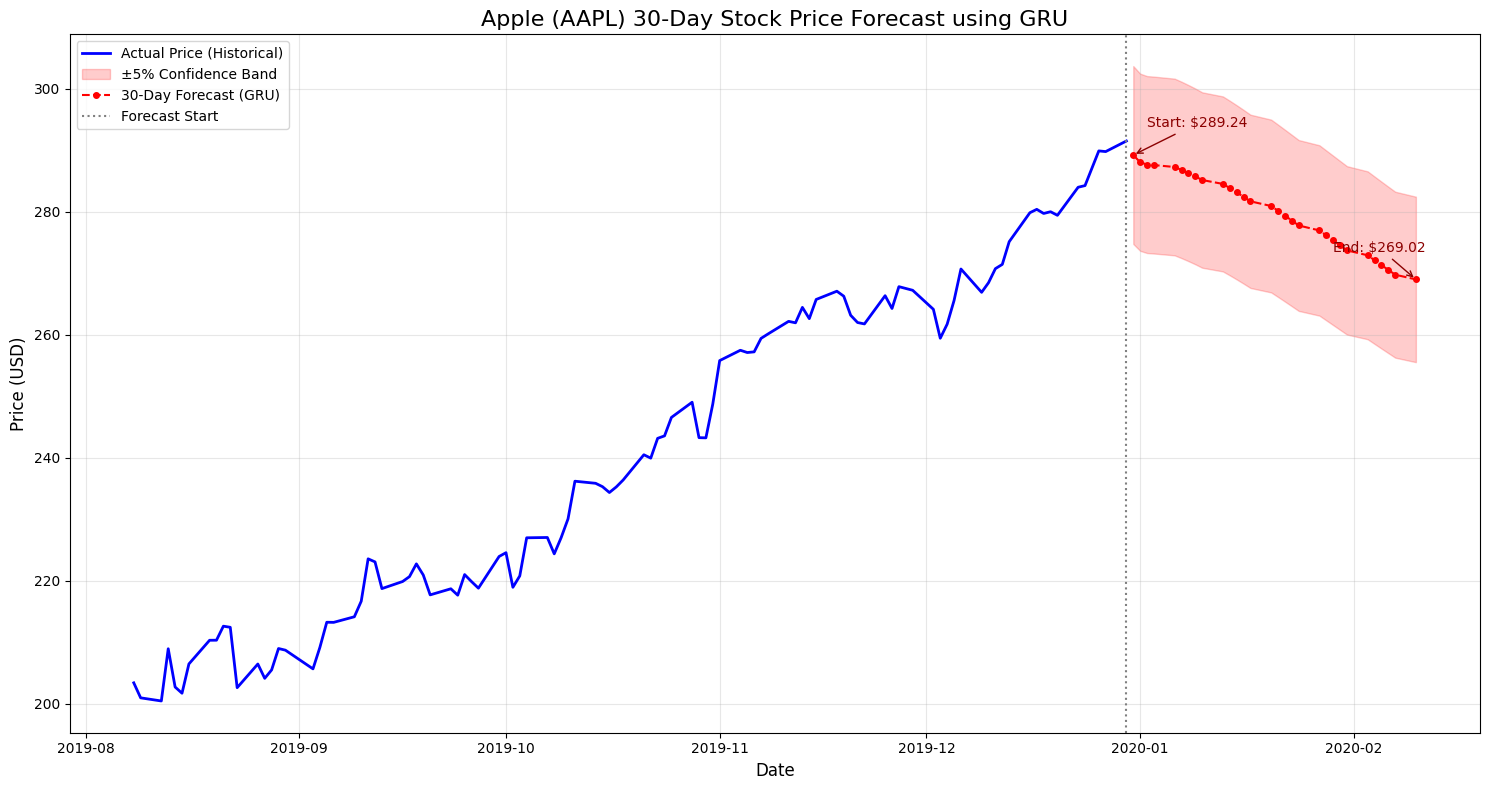


--- 30-Day Forecast Summary ---
Forecast Start Date : 2019-12-31
Forecast End Date   : 2020-02-10
Starting Price      : $289.24
Final Price         : $269.02
Expected Change     : -6.99%

Full 30-Day Forecast Table:
            Predicted Close ($)
2019-12-31           289.239166
2020-01-01           288.066711
2020-01-02           287.690216
2020-01-03           287.605499
2020-01-06           287.292877
2020-01-07           286.817322
2020-01-08           286.305359
2020-01-09           285.764771
2020-01-10           285.175873
2020-01-13           284.541718
2020-01-14           283.873230
2020-01-15           283.176422
2020-01-16           282.454468
2020-01-17           281.710907
2020-01-20           280.949493
2020-01-21           280.173492
2020-01-22           279.385895
2020-01-23           278.589172
2020-01-24           277.785950
2020-01-27           276.978271
2020-01-28           276.168121
2020-01-29           275.357422
2020-01-30           274.547760
2020-01-31     

In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# 1. RETRAIN: Using a dedicated final scaler fit on ALL data once to avoid leakage
final_scaler_gru = MinMaxScaler(feature_range=(0, 1))
full_scaled_data = final_scaler_gru.fit_transform(apple_df_cleaned[['Close']].values)

final_time_steps = 60
final_units = 100
final_dropout = 0.2

X_final, y_final = create_lstm_sequences(full_scaled_data, final_time_steps)
X_final = X_final.reshape(X_final.shape[0], X_final.shape[1], 1)

final_gru_model = Sequential([
    GRU(final_units, return_sequences=True, input_shape=(final_time_steps, 1)),
    Dropout(final_dropout),
    GRU(final_units, return_sequences=False),
    Dropout(final_dropout),
    Dense(25),
    Dense(1)
])
final_gru_model.compile(optimizer='adam', loss='mean_squared_error')
final_gru_model.fit(X_final, y_final, epochs=100, batch_size=16, verbose=0)

# 2. RECURSIVE FORECAST
forecast_horizon = 30
last_sequence = full_scaled_data[-final_time_steps:]
predictions_30_scaled = []

for i in range(forecast_horizon):
    input_seq = last_sequence.reshape(1, final_time_steps, 1)
    pred_scaled = final_gru_model.predict(input_seq, verbose=0)
    predictions_30_scaled.append(pred_scaled[0, 0])
    last_sequence = np.append(last_sequence[1:], pred_scaled[0, 0])

# 3. INVERSE TRANSFORM & DATES
predictions_30 = final_scaler_gru.inverse_transform(np.array(predictions_30_scaled).reshape(-1, 1))
last_date = apple_df_cleaned.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon)
forecast_table = pd.DataFrame({'Predicted Close ($)': predictions_30.flatten()}, index=future_dates)

# 4. Final Visualization with Confidence Band
plt.figure(figsize=(15, 8))

# Actual historical data (last 100 days for context)
historical_subset = apple_df_cleaned['Close'].tail(100)
plt.plot(historical_subset.index, historical_subset.values,
         label='Actual Price (Historical)', color='blue', linewidth=2)

# Confidence band (±5% around forecast)
lower_bound = forecast_table['Predicted Close ($)'] * 0.95
upper_bound = forecast_table['Predicted Close ($)'] * 1.05
plt.fill_between(forecast_table.index, lower_bound, upper_bound,
                 alpha=0.2, color='red', label='±5% Confidence Band')

# Forecast line
plt.plot(forecast_table.index, forecast_table['Predicted Close ($)'],
         label='30-Day Forecast (GRU)', color='red',
         linestyle='--', marker='o', markersize=4)

# Forecast boundary line
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.5,
            label='Forecast Start')

# Annotate start and end forecast price
start_price = forecast_table['Predicted Close ($)'].iloc[0]
end_price = forecast_table['Predicted Close ($)'].iloc[-1]

plt.annotate(f'Start: ${start_price:.2f}',
             xy=(forecast_table.index[0], start_price),
             xytext=(10, 20), textcoords='offset points',
             fontsize=10, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred'))

plt.annotate(f'End: ${end_price:.2f}',
             xy=(forecast_table.index[-1], end_price),
             xytext=(-60, 20), textcoords='offset points',
             fontsize=10, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred'))

plt.title('Apple (AAPL) 30-Day Stock Price Forecast using GRU', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print(f"\n--- 30-Day Forecast Summary ---")
print(f"Forecast Start Date : {forecast_table.index[0].date()}")
print(f"Forecast End Date   : {forecast_table.index[-1].date()}")
print(f"Starting Price      : ${start_price:.2f}")
print(f"Final Price         : ${end_price:.2f}")
print(f"Expected Change     : {((end_price - start_price) / start_price) * 100:.2f}%")
print(f"\nFull 30-Day Forecast Table:")
print(forecast_table.to_string())

In [268]:
# Re-run validate_forecast to check the production GRU forecast
validate_forecast(apple_df_cleaned['Close'].tail(60),
                  forecast_table['Predicted Close ($)'].values)

--- Forecast Validation Metrics ---
Starting Price: $291.52
Final Forecasted Price: $269.02
Total Expected Change: -7.72%
Historical Daily Volatility: 0.0106
Forecasted Daily Volatility: 0.0007
ℹ️ Note: Forecasted volatility is very low; common in recursive deep learning models as they converge to a mean.


In [269]:
import pickle
import os

save_dir = '/content/streamlit_assets'   # Google Colab path
os.makedirs(save_dir, exist_ok=True)

# 1. Save the trained GRU model
final_gru_model.save(f'{save_dir}/final_gru_model.keras')
print("✅ Model saved")

# 2. Save the scaler
with open(f'{save_dir}/final_scaler_gru.pkl', 'wb') as f:
    pickle.dump(final_scaler_gru, f)
print("✅ Scaler saved")

# 3. Save the cleaned dataframe
apple_df_cleaned.to_pickle(f'{save_dir}/apple_df_cleaned.pkl')
print("✅ DataFrame saved")

print("\nAll assets saved to:", save_dir)
print("Files:", os.listdir(save_dir))

✅ Model saved
✅ Scaler saved
✅ DataFrame saved

All assets saved to: /content/streamlit_assets
Files: ['apple_df_cleaned.pkl', 'final_gru_model.keras', 'final_scaler_gru.pkl']


In [270]:
from google.colab import files
files.download(f'{save_dir}/final_gru_model.keras')
files.download(f'{save_dir}/final_scaler_gru.pkl')
files.download(f'{save_dir}/apple_df_cleaned.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>